# Exercise 1

In [2]:
def LCG(m, a, c, n, seed=2443):
    """
    Generates a sequence of pseudo-random numbers. Returns float between 0 and 1.
    """
    state = seed
    sequence = []
    
    for _ in range(n):
        state = (a * state + c) % m
        
        # Divide by the upper limit to make sure that it is between 0 and 1
        sequence.append(state / m)
        
    return sequence

## a) Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme 

In [3]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

Manual Bin Counts (10 classes): [1014, 971, 994, 1006, 979, 1001, 1015, 1001, 1018, 1001]


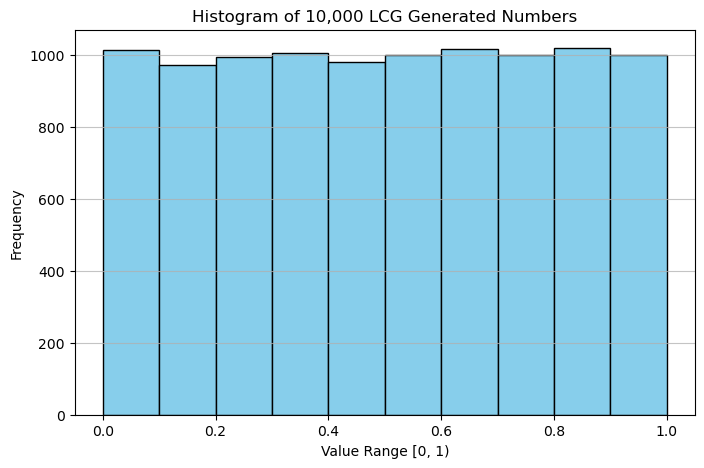

In [19]:
# Generate 10,000 pseudo-random numbers
random_numbers = LCG(m=2**32, a=1664525, c=1013904223, n=10000)

def custom_histogram(data, num_bins=10):
    """Manually counts how many numbers fall into each of the 10 classes"""
    bins = [0] * num_bins
    for val in data:
        # Multiply by 10 and truncate to get the bin index (0 to 9)
        idx = int(val * num_bins)
        if idx == num_bins: 
            idx -= 1 # Edge case handler just in case a value is exactly 1.0
        bins[idx] += 1
    return bins

bin_counts = custom_histogram(random_numbers, num_bins=10)
print(f"Manual Bin Counts (10 classes): {bin_counts}")

# Second, visualizing it using matplotlib:
plt.figure(figsize=(8, 5))
plt.hist(random_numbers, bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of 10,000 LCG Generated Numbers")
plt.xlabel("Value Range [0, 1)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

## b)

In [6]:
import math

### Histogram and scatter plot of the simulated random numbers

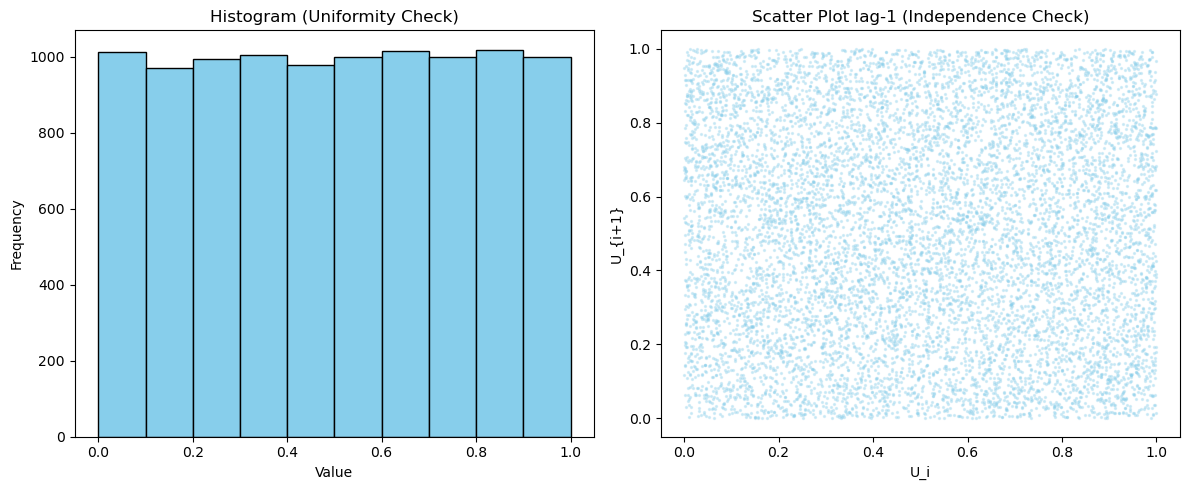

In [20]:
# --- Graphical Descriptive Statistics ---
def plot_visuals(data):
    """Generates a histogram and a scatter plot"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram
    ax1.hist(data, bins=10, color='skyblue', edgecolor='black')
    ax1.set_title("Histogram (Uniformity Check)")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Frequency")
    
    # Scatter plot of Ui vs U_{i+1}
    ax2.scatter(data[:-1], data[1:], alpha=0.3, s=2, color='skyblue')
    ax2.set_title("Scatter Plot lag-1 (Independence Check)")
    ax2.set_xlabel("U_i")
    ax2.set_ylabel("U_{i+1}")
    
    plt.tight_layout()
    plt.show()

plot_visuals(random_numbers)

### Statistical tests

In [21]:
# Chi-squared test
def chi_square_test(data, num_bins=10):
    """
    Chi-Square test for distribution type
    """
    n = len(data)
    expected = n / num_bins
    bins = custom_histogram(data, num_bins) # The histogram function from 1 a)
    
    t_stat = 0  # Start the sum at zero

    for observed in bins:
        t_stat += ((observed - expected)**2) / expected
    return t_stat


In [22]:
# Kolmogorovs distribution test, the case where all parameters are known

def KS_test(data):
    """
    Kolmogorov Smirnov test for Uniform(0,1).
    Uses the 'All parameters known' statistic.
    """
    n = len(data)
    sorted_data = sorted(data)
    
    # Calculate the standard test statistic D_n = sup_x |F_n(x) - F(x)|
    # F_n(x): the empirical step function, F(x): The theoretical function

    # Max distance where the empirical step function sits ABOVE the theoretical function
    d_plus = max((i + 1)/n - sorted_data[i] for i in range(n))
    # Max distance where the empirical function sits below the theoretical function
    d_minus = max(sorted_data[i] - i/n for i in range(n))
    # The maximal difference between the theoretical and the empirical function
    dn = max(d_plus, d_minus)
    
    # Apply the 'All parameters known' adjustment formula
    test_stat = (math.sqrt(n) + 0.12 + (0.11 / math.sqrt(n))) * dn
    
    return test_stat

In [23]:
# Run test: Above/below
import statistics

def runs_test_above_below(data):
    """
    The above/below median run test for independence.
    """

    median_value = statistics.median(data)
    
    # Classify observations as above (+1) or below (-1) the median.
    classified = [] # initilize and empty list for the classification values
    for x in data:
        if x > median_value:
            classified.append(1)
        elif x < median_value:
            classified.append(-1)
            
    # Count the number of values above (n1) and below (n2) the median
    n1 = classified.count(1)
    n2 = classified.count(-1)
    
    # Count total runs (T = R_a + R_b). 
    # R_a: runs above the median, R_b: runs below the median
    T = 1
    for i in range(1, len(classified)):
        if classified[i] != classified[i-1]:    # every time it shifts sides of the median
            T += 1
            
    # Calculate expected mean and variance
    mean = (2 * n1 * n2) / (n1 + n2) + 1
    variance = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    
    # Calculate Z-score: Z ~ Normal(0, 1)
    z_score = (T - mean) / math.sqrt(variance)
    
    return z_score

In [24]:
# Run test: up-and-down
def runs_test_up_down(data):
    """
    The up-and-down run test for independence.
    """
    n = len(data)
    signs = [1 if data[i] > data[i-1] else -1 for i in range(1, n)]
    
    runs = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            runs += 1   # how often the signs flip
            
    # Z-score formula
    expected_runs = (2 * n - 1) / 3
    variance = (16 * n - 20) / 90
    z_score = (runs - expected_runs) / math.sqrt(variance)
    return z_score

In [ ]:
def correlation_test(data, h):
    """
    Test for correlation coefficients.
    c_h ~ Normal(0.25, 7 / (144*n))
    """
    n = len(data)
    if n <= h: return 0
    
    c_h = (sum(data[i] * data[i+h] for i in range(n - h))) / (n - h)

    z_score = (c_h - 0.25) / math.sqrt(7 / (144 * n))
    return z_score

### Running the tests
Evaluating the generator,by running the tests on the random_numbers we simulated in 1 a)

In [ ]:
# Execute all statistical tests on the generated sequence
print("Statistical Test Results:")
print(f"Chi-Square Statistic: {chi_square_test(random_numbers):.4f}")
print(f"KS Adjusted Stat:     {KS_test(random_numbers):.4f} (Rejected if > 1.480)")
print(f"Runs (Above/Below):   {runs_test_above_below(random_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Runs (Up-and-Down):   {runs_test_up_down(random_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=1):    {correlation_test(random_numbers, 1):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=5):    {correlation_test(random_numbers, 5):.4f} (Rejected if absolute value > 1.96)")

Statistical Test Results:
Chi-Square Statistic: 2.1020
KS Adjusted Stat:     0.6989 (Rejected if > 1.480)
Runs (Above/Below):   0.8000 (Rejected if absolute values > 1.96)
Runs (Up-and-Down):   0.0870 (Rejected if absolute values > 1.96)
Correlation (h=1):    0.3094 (Rejected if absolute values > 1.96)
Correlation (h=5):    1.0278 (Rejected if absolute values > 1.96)


## c) Experimenting with parameters
We will test a generator with a very small modulus (m=16, a=5, c=1) and compare it against our choise of numbers above (m=2**32, a=1664525, c=1013904223).

Statistical Test Results with parameters: m=16, a=5, c=1
Chi-Square Statistic: 937.5000
KS Adjusted Stat:     6.2576 (Rejected if > 1.480)
Runs (Above/Below):   -25.0013 (Rejected if absolute values > 1.96)
Runs (Up-and-Down):   -9.8985 (Rejected if absolute values > 1.96)
Correlation (h=1):    -3.5480 (Rejected if absolute values > 1.96)
Correlation (h=5):    -10.6618 (Rejected if absolute values > 1.96)


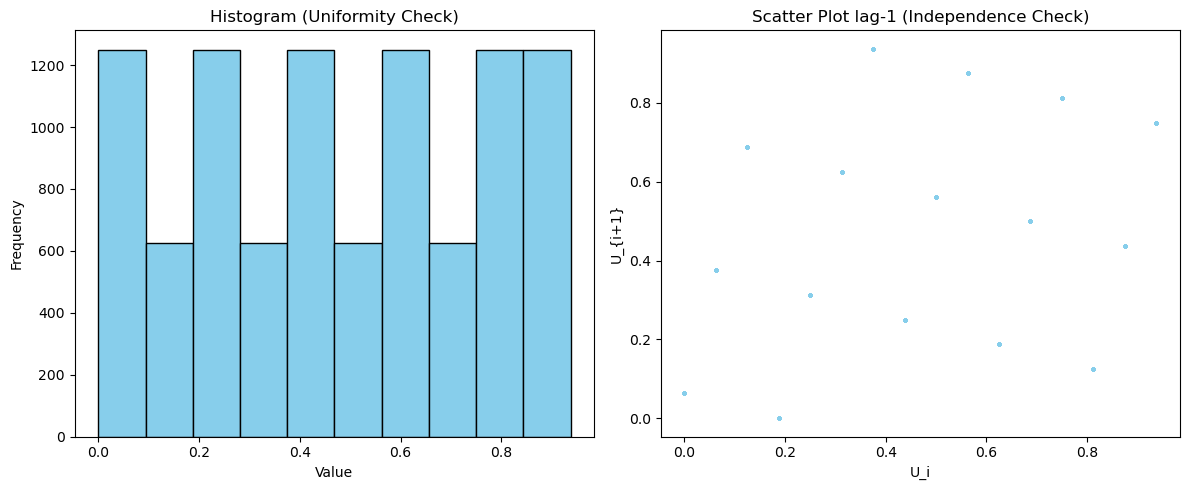

In [ ]:
bad_numbers = LCG(m=16, a=5, c=1, n=10000)

print("Statistical Test Results with parameters: m=16, a=5, c=1")
print(f"Chi-Square Statistic: {chi_square_test(bad_numbers):.4f}")
print(f"KS Adjusted Stat:     {KS_test(bad_numbers):.4f} (Rejected if > 1.480)")
print(f"Runs (Above/Below):   {runs_test_above_below(bad_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Runs (Up-and-Down):   {runs_test_up_down(bad_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=1):    {correlation_test(bad_numbers, 1):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=5):    {correlation_test(bad_numbers, 5):.4f} (Rejected if absolute value > 1.96)")

plot_visuals(bad_numbers)

We can see a clear structure in the plots. Also all the test reject the hypotosis. Therefore, these are bad numbers.

## 2. Apply a system available generator and perform the various statistical tests you did under Part 1 point (b) for this generator too

Testing Python's built-in Mersenne Twister generator using the exact same framework.

Statistical Test Results with parameters: m=16, a=5, c=1
Chi-Square Statistic: 17.4900
KS Adjusted Stat:     1.5026 (Rejected if > 1.480)
Runs (Above/Below):   0.0200 (Rejected if absolute values > 1.96)
Runs (Up-and-Down):   0.8697 (Rejected if absolute values > 1.96)
Correlation (h=1):    -3.9691 (Rejected if absolute values > 1.96)
Correlation (h=5):    -3.7425 (Rejected if absolute values > 1.96)


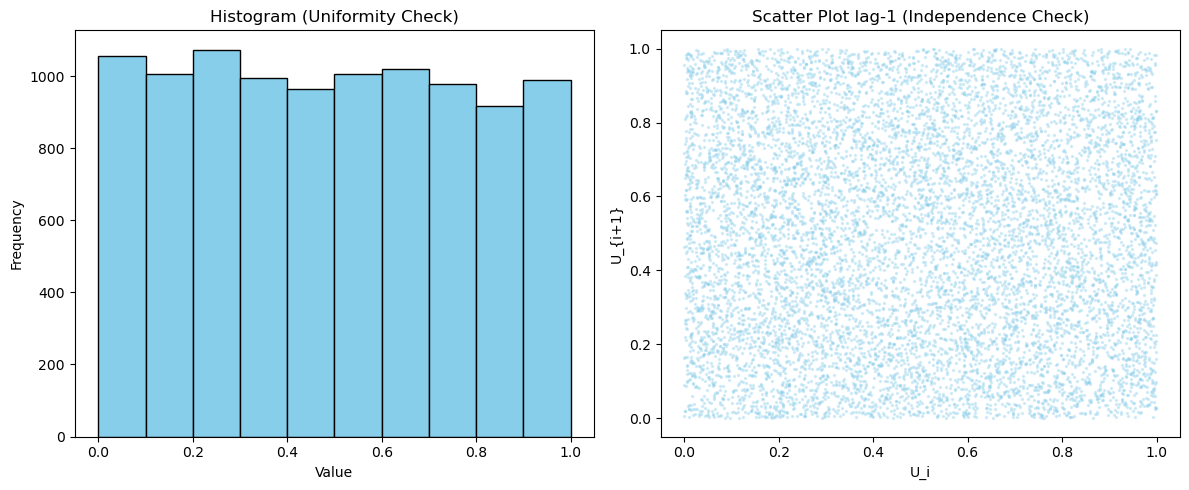

In [ ]:
# importing the random generator, which is the Mersenne Twister generator
import random

# Generate 10000 numbers using Python's built-in generator
sys_numbers = [random.random() for n in range(10000)]

print("Statistical Test Results with parameters: m=16, a=5, c=1")
print(f"Chi-Square Statistic: {chi_square_test(sys_numbers):.4f}")
print(f"KS Adjusted Stat:     {KS_test(sys_numbers):.4f} (Rejected if > 1.480)")
print(f"Runs (Above/Below):   {runs_test_above_below(sys_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Runs (Up-and-Down):   {runs_test_up_down(sys_numbers):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=1):    {correlation_test(sys_numbers, 1):.4f} (Rejected if absolute value > 1.96)")
print(f"Correlation (h=5):    {correlation_test(sys_numbers, 5):.4f} (Rejected if absolute value > 1.96)")

plot_visuals(sys_numbers)

Visually it looks quite similar to the our LCG with the final values. Looks pretty uniformly distributes.

## 3)
Testing a single sample of 10,000 numbers isn't enough, since a good generator can fail 5% of the time by pure chance, and a bad generator can get lucky once. Therefore we should run multiple replications.

In [35]:
import matplotlib.pyplot as plt

In [37]:
def test_replications(num_replications=1000, sample_size=10000):
    """
    Running all statistical tests 1000 times on independent samples to observe the global Type I error rates across the entire framework.
    """
    # Initialize failure counters for each test
    fails_chi = 0
    fails_ks = 0
    fails_above_below = 0
    fails_up_down = 0
    fails_corr = 0
    
    for n in range(num_replications):
        # Generate a brand new independent sample using the system generator
        sample = [random.random() for _ in range(sample_size)]
        
        # Execute all tests and check their respective thresholds
        
        # Chi-Square threshold: 16.92
        if chi_square_test(sample) >= 16.92:
            fails_chi += 1
            
        # KS test threshold: 1.480
        if KS_test(sample) >= 1.480:
            fails_ks += 1
            
        # Above/Below threshold: outside [-1.96, 1.96]
        z_ab = runs_test_above_below(sample)
        if z_ab <= -1.96 or z_ab >= 1.96:
            fails_above_below += 1
            
        # Up/Down threshold: outside [-1.96, 1.96]
        z_ud = runs_test_up_down(sample)
        if z_ud <= -1.96 or z_ud >= 1.96:
            fails_up_down += 1
            
        # Correlation (h=1) threshold: outside [-1.96, 1.96]
        z_corr = correlation_test(sample, h=1)
        if z_corr <= -1.96 or z_corr >= 1.96:
            fails_corr += 1

    
    print(f"Statistical test results with {num_replications} replications")
    print(f"Chi-Square Failures:    {fails_chi}/{num_replications} ({ (fails_chi/num_replications)*100 :.2f}%)")
    print(f"KS Test Failures:       {fails_ks}/{num_replications} ({ (fails_ks/num_replications)*100 :.2f}%)")
    print(f"Runs (Above/Below):     {fails_above_below}/{num_replications} ({ (fails_above_below/num_replications)*100 :.2f}%)")
    print(f"Runs (Up/Down):         {fails_up_down}/{num_replications} ({ (fails_up_down/num_replications)*100 :.2f}%)")
    print(f"Correlation (h=1):      {fails_corr}/{num_replications} ({ (fails_corr/num_replications)*100 :.2f}%)")

# Execute the comprehensive replications
test_replications(num_replications=1000, sample_size=10000)

Statistical test results with 1000 replications
Chi-Square Failures:    43/1000 (4.30%)
KS Test Failures:       26/1000 (2.60%)
Runs (Above/Below):     46/1000 (4.60%)
Runs (Up/Down):         41/1000 (4.10%)
Correlation (h=1):      145/1000 (14.50%)


Note that for a 95% confidence level, the expected theoretical failure rate for each test is about 5%. We notice that the first four tests are around this, but the correlation test with h=1 is higher.


# Exercise 2

## Part 1


In [1]:
import numpy as np
import pandas as pd
np.random.seed(2443)

In [2]:
# Number of samples
N = 10000

# probability parameter 
P = 0.5

# The geometric distribution
def sample_geometric(p, n):
    U = np.random.uniform(0, 1, n)
    
    X = np.floor(np.log(U) / np.log(1 - p)).astype(int) + 1
    return X

# The geometric distibution from numpy
simulated = np.random.geometric(p=0.5, size=10000)
print(simulated)

[1 2 1 ... 8 4 2]


In [3]:
# Parameters
p=0.5
N=10000
np.random.seed(2443)

# Theoretical metrics
theoretical_mean = 1 / p
theoretical_var = (1 - p) / (p**2)

# Compare Results
data = {
    "Metric": ["Mean", "Variance"],
    "Theoretical": [theoretical_mean, theoretical_var],
    "Simulated": [np.mean(simulated), np.var(simulated)]
}

print(pd.DataFrame(data).to_string(index=False))

  Metric  Theoretical  Simulated
    Mean          2.0   2.000900
Variance          2.0   1.897299


## Part 2

We will generate observations from the given distribution using:

1. the direct (crude) method,
2. the rejection method,
3. the alias method

In [ ]:
# The direct (crude) method
np.random.seed(2443)
def sample_direct(p, size=N):

    # Compute cumulative distribution function (CDF)
    P_cdf = np.cumsum(p)

    # U is uniform between 0 and 1
    U = np.random.uniform(0, 1, size)

    # np.searchsorted finds exactly where each value of U fits into the CDF bins.
    indices = np.searchsorted(P_cdf, U)
    
    # Since our indices start at 0, but our outcomes are 1 through 6, we add 1
    X = indices + 1
    
    return X

# Target probabilities
p_target = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

simulated_direct = sample_direct(p_target)

print(simulated_direct)

[3 5 1 ... 6 6 5]


In [6]:
# The (general) rejection method

def sample_rejection(p, q, size=N):
    """
    p: Target probability array
    q: Proposal probability array
    """
    # Choose a constant c
    c = np.max(p / q) +1
    k = len(p)
    
    samples = np.empty(size, dtype=int)
    accepted_count = 0
    
    while accepted_count < size:
        # Step 1: Generate Y according to the proposal distribution q
        Y = np.random.randint(0, k, size - accepted_count)  # Q is uniform
        
        # Step 2: Check the acceptance condition
        U = np.random.uniform(0, 1, size - accepted_count)
        accept = U <= p[Y] / (c * q[Y])
        
        # Store accepted values
        num_accepted = np.sum(accept)
        if num_accepted > 0:
            samples[accepted_count : accepted_count + num_accepted] = Y[accept] + 1
            accepted_count += num_accepted
            
    return samples


# Target probabilities
p_target = np.array([7/48, 5/48, 6/48, 3/48, 12/48, 15/48])

# Proposal probabilities (Uniform: 1/6 for each of the 6 outcomes)
q_proposal = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

# Run the algorithm
np.random.seed(2443)
simulated_rejection = sample_rejection(p_target, q_proposal)

# Let's verify the results
observed_counts = np.bincount(simulated_rejection)[1:]
empirical_probs = observed_counts / 10000

print("Target Probabilities:   ", np.round(p_target, 4))
print("Empirical Probabilities:", np.round(empirical_probs, 4))

Target Probabilities:    [0.1458 0.1042 0.125  0.0625 0.25   0.3125]
Empirical Probabilities: [0.1447 0.1043 0.1253 0.0627 0.2534 0.3096]


In [7]:
# The alias method
from scipy.stats.sampling import DiscreteAliasUrn

# Target probabilities for the six-point distribution
p_target = np.array([7/48, 5/48, 6/48, 3/48, 12/48, 15/48])
N = 10000
np.random.seed(2443)

# The Preprocessing Step
# This creates the "Alias tables" and normalizes the probabilities.
alias_generator = DiscreteAliasUrn(p_target, random_state=2443)

# The Generation Step
simulated_alias = alias_generator.rvs(size=N)

simulated_alias += 1 

observed_counts = np.bincount(simulated_alias)[1:]
empirical_probs = observed_counts / N

print("Alias Method Results:")
print("Target Probabilities:   ", np.round(p_target, 4))
print("Empirical Probabilities:", np.round(empirical_probs, 4))

Alias Method Results:
Target Probabilities:    [0.1458 0.1042 0.125  0.0625 0.25   0.3125]
Empirical Probabilities: [0.1437 0.1043 0.1219 0.0644 0.2574 0.3083]


## Part 3
Comparing the three generation methods

In [18]:
import pandas as pd
import time
from scipy.stats.sampling import DiscreteAliasUrn

# Target probabilities for the six-point distribution
p_target = np.array([7/48, 5/48, 6/48, 3/48, 12/48, 15/48])
outcomes = np.arange(1, 7)
N = 10000
np.random.seed(2443)


# timing the three methods
t0 = time.perf_counter()
sim_direct = sample_direct(p_target)
time_direct = time.perf_counter() - t0

t0 = time.perf_counter()
sim_rejection = sample_rejection(p_target, q_proposal)
time_rejection = time.perf_counter() - t0

t0 = time.perf_counter()
alias_generator = DiscreteAliasUrn(p_target, random_state=2443)
sim_alias = alias_generator.rvs(size=N) + 1
time_alias = time.perf_counter() - t0


# Calculate empirical probabilities
prob_direct = np.bincount(sim_direct)[1:] / N
prob_reject = np.bincount(sim_rejection)[1:] / N
prob_alias = np.bincount(sim_alias)[1:] / N

# Create an accuracy comparison table
accuracy_df = pd.DataFrame({
    'Outcome': outcomes,
    'Theoretical': np.round(p_target, 4),
    'Direct': np.round(prob_direct, 4),
    'Rejection': np.round(prob_reject, 4),
    'Alias': np.round(prob_alias, 4)
})

print("Accuracy comparison:")
print(accuracy_df.to_string(index=False))

# Print Execution Times
print("\n Computational efficiency")
print(f"Samples generated: {N}")
print(f"Direct Method:    {time_direct:.5f} seconds")
print(f"Rejection Method: {time_rejection:.5f} seconds")
print(f"Alias Method:     {time_alias:.5f} seconds")

Accuracy comparison:
 Outcome  Theoretical  Direct  Rejection  Alias
       1       0.1458  0.1437     0.1412 0.1437
       2       0.1042  0.1020     0.1021 0.1043
       3       0.1250  0.1238     0.1270 0.1219
       4       0.0625  0.0625     0.0646 0.0644
       5       0.2500  0.2514     0.2552 0.2574
       6       0.3125  0.3166     0.3099 0.3083

 Computational efficiency
Samples generated: 10000
Direct Method:    0.00049 seconds
Rejection Method: 0.00288 seconds
Alias Method:     0.00212 seconds


# Exercise 3
Generate simulated values from the following distributions

(a) Exponential distribution

(b) Normal distribution (at least with standard Box-Mueller)

(c) Pareto distribution, with β = 1 and experiment with different values of k values: k = 2.05, k = 2.5, k = 3 and k = 4

In [19]:
from scipy import stats

# Set seed for reproducibility and define number of samples
np.random.seed(2443)
N = 10000

# 1.a) Sampling from the exponential distribution
# Formula: Y = -log(U) / lambda
lam = 1.0
U_exp = np.random.uniform(0, 1, N)
exp_sim = -np.log(U_exp) / lam

print(exp_sim)

[1.28400092 0.55084044 2.00931001 ... 0.00661789 0.08070014 0.64698644]


In [20]:
# 1.b) Normal distribution (at least with standard Box-Mueller)

# Arrays of random numbers, each containing half the numbsers of N(the total number of samples)
U1 = np.random.uniform(0, 1, N // 2)
U2 = np.random.uniform(0, 1, N // 2)

# The polar coordinate transformation
R = np.sqrt(-2 * np.log(U1))    # radius
Theta = 2 * np.pi * U2  # the angle

# Converting back to standard cartesian coordinates
Z0 = R * np.cos(Theta)
Z1 = R * np.sin(Theta)
norm_sim = np.concatenate((Z0, Z1)) # combining into a single array of size N

print(f"Simulated Mean: {np.mean(norm_sim):.4f} | Theoretical: 0.0000")
print(f"Simulated Var:  {np.var(norm_sim):.4f} | Theoretical: 1.0000")

Simulated Mean: -0.0187 | Theoretical: 0.0000
Simulated Var:  1.0347 | Theoretical: 1.0000


In [21]:
# 1.c) Pareto distribution, with beta = 1 and experiment with different values of k values: k = 2.05, k = 2.5, k = 3 and k = 4.

# Formula: Y = beta * U^(-1/k)
beta = 1.0
k_values = [2.05, 2.5, 3.0, 4.0]
pareto_sims = {}

for k in k_values:
    U_par = np.random.uniform(0, 1, N)
    pareto_sims[k] = beta * (U_par ** (-1 / k))


We now verify the results by comparing histograms with analytical results and perform tests for distribution type.


 Kolmogorov-Smirnov test:
Exponential K-S Test: p-value = 0.2504
Normal K-S Test:      p-value = 0.0417
Pareto (k=2.05) K-S Test: p-value = 0.4754
Pareto (k=2.5) K-S Test: p-value = 0.5796
Pareto (k=3.0) K-S Test: p-value = 0.8174
Pareto (k=4.0) K-S Test: p-value = 0.8089


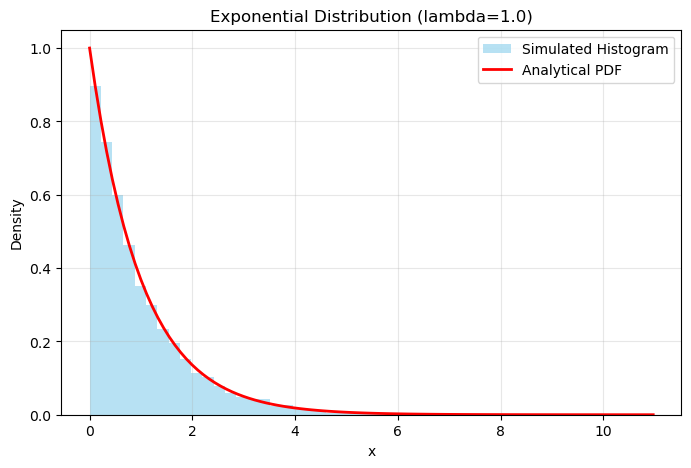

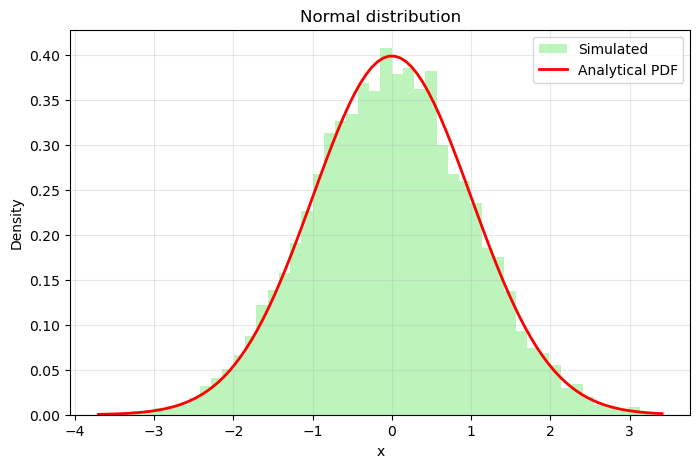

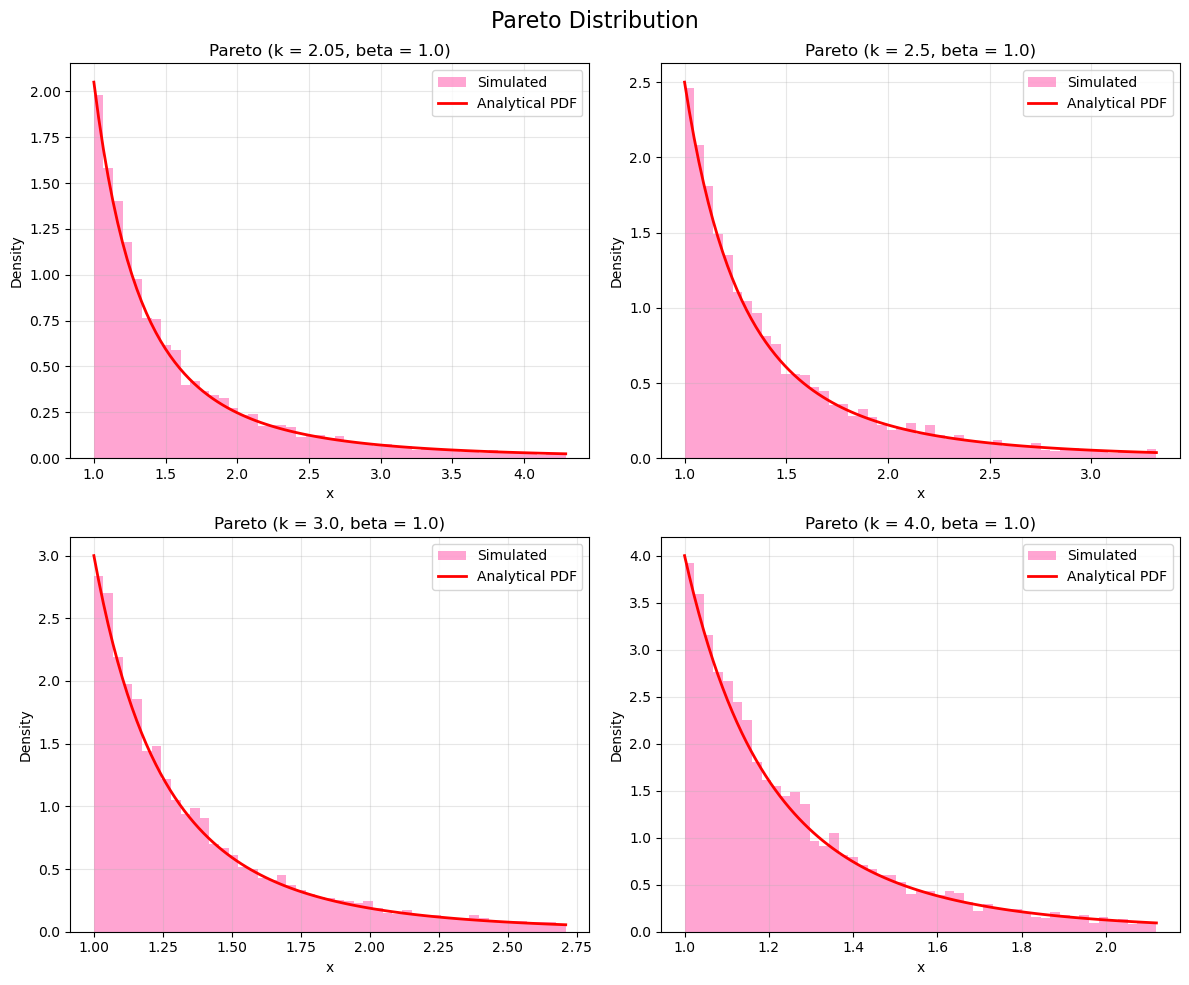

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

print("\n Kolmogorov-Smirnov test:")

# Exponential Test
ks_exp = stats.kstest(exp_sim, 'expon', args=(0, 1/lam))
print(f"Exponential K-S Test: p-value = {ks_exp.pvalue:.4f}")

# Normal Test (mean=0, std=1)
ks_norm = stats.kstest(norm_sim, 'norm', args=(0, 1))
print(f"Normal K-S Test:      p-value = {ks_norm.pvalue:.4f}")

# Pareto Tests
for k in k_values:
    ks_pareto = stats.kstest(pareto_sims[k], 'pareto', args=(k, 0, beta))
    print(f"Pareto (k={k}) K-S Test: p-value = {ks_pareto.pvalue:.4f}")


# Histograms vs analytical results
# Exponential plot
plt.figure(figsize=(8, 5))
plt.hist(exp_sim, bins=50, density=True, alpha=0.6, color='skyblue', label='Simulated Histogram')
x_exp = np.linspace(0, np.max(exp_sim), 100)
plt.plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam), 'r-', lw=2, label='Analytical PDF')
plt.title('Exponential Distribution (lambda=1.0)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Normal plot
plt.figure(figsize=(8, 5))
plt.hist(norm_sim, bins=50, density=True, alpha=0.6, color='lightgreen', label='Simulated')
x_norm = np.linspace(np.min(norm_sim), np.max(norm_sim), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, loc=0, scale=1), 'r-', lw=2, label='Analytical PDF')
plt.title('Normal distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Pareto plots (2x2 Grid for the 4 k values)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Pareto Distribution', fontsize=16)

for ax, k in zip(axes.flatten(), k_values):
    # Pareto has extreme tails. To make the histogram readable, we limit the x-axis to the 95th percentile of the simulated data.
    xmax = np.percentile(pareto_sims[k], 95)
    bins = np.linspace(beta, xmax, 50)
    
    ax.hist(pareto_sims[k], bins=bins, density=True, alpha=0.6, color='hotpink', label='Simulated')
    
    # Analytical PDF: f(x) = (k * beta^k) / x^(k+1)
    x_par = np.linspace(beta, xmax, 100)
    ax.plot(x_par, stats.pareto.pdf(x_par, k, scale=beta), 'r-', lw=2, label='Analytical PDF')
    
    ax.set_title(f'Pareto (k = {k}, beta = {beta})')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice that all the p-values are larger than 0.05, indicating that all the simulations are valid.

## 2. Compare the mean and variance for the pareto distribution with support [beta, infinity[ with analytical results

In [25]:
for k in k_values:

    # the simulated values
    sim_mean = np.mean(pareto_sims[k])
    sim_var = np.var(pareto_sims[k], ddof=1)
    
    # The analytical values
    theo_mean = (beta * k) / (k - 1)
    theo_var = (beta**2 * k) / (((k - 1)**2) * (k - 2))
    
    print(f"\nPareto (k={k}):")
    print(f"  Mean: Simulated = {sim_mean:.4f} | Theoretical = {theo_mean:.4f}")
    print(f"  Var:  Simulated = {sim_var:.4f} | Theoretical = {theo_var:.4f}")


Pareto (k=2.05):
  Mean: Simulated = 1.9114 | Theoretical = 1.9524
  Var:  Simulated = 3.8078 | Theoretical = 37.1882

Pareto (k=2.5):
  Mean: Simulated = 1.6543 | Theoretical = 1.6667
  Var:  Simulated = 1.2928 | Theoretical = 2.2222

Pareto (k=3.0):
  Mean: Simulated = 1.5062 | Theoretical = 1.5000
  Var:  Simulated = 0.7788 | Theoretical = 0.7500

Pareto (k=4.0):
  Mean: Simulated = 1.3309 | Theoretical = 1.3333
  Var:  Simulated = 0.2162 | Theoretical = 0.2222


We notice that in the case k=2.05 the simulated variance is far from the theoretical variance. This is because k is so close to 2, the theoretical variance explodes (the denominator is really small so the full fraction gets huge), and rare extreme tail values dictate the outcome. But in all other cases the man and variances are really similar.

## 3. For the normal distribution generate 100 95% confidence intervals for the mean and variance, each based on 10 observations

In [33]:
n_intervals = 100   # number of intervals to generate
n_obs = 10          # number of observations to use

# Initilize empty list to store the intervals
mean_intervals = []
var_intervals = []
samples = []


for i in range(n_intervals):

    # Generate 10(n_obs) observations from a standard normal distribution
    sample = np.random.normal(0, 1, n_obs)
    samples.append(sample)
    
    # Extracting the mean and variance
    x_bar = np.mean(sample)
    s2 = np.var(sample, ddof=1)
    
    # 95% CI for the mean (using t-distribution)
    t_crit = stats.t.ppf(0.975, df=n_obs-1)
    mean_margin = t_crit * np.sqrt(s2 / n_obs)
    
    ci_mean_lower = x_bar - mean_margin
    ci_mean_upper = x_bar + mean_margin
    mean_intervals.append((ci_mean_lower, ci_mean_upper))   # adding the interval to the list
    
    # 95% CI for the Variance (using Chi-Square distribution)
    chi2_lower = stats.chi2.ppf(0.025, df=n_obs-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n_obs-1)
    
    ci_var_lower = (n_obs - 1) * s2 / chi2_upper
    ci_var_upper = (n_obs - 1) * s2 / chi2_lower
    var_intervals.append((ci_var_lower, ci_var_upper))  # adding the interval to the list


print(f"{'Simulation #':<15} | {'95% CI for Mean':<30} | {'95% CI for Variance'}")
print("-" * 70)

# Print the first 10 intervals as an example so it doesn't flood the console
for i in range(10):
    m_low, m_up = mean_intervals[i]
    v_low, v_up = var_intervals[i]
    print(f"Simulation {i+1:<4} | [{m_low:>7.4f}, {m_up:>7.4f}]           | [{v_low:>7.4f}, {v_up:>7.4f}]")



Simulation #    | 95% CI for Mean                | 95% CI for Variance
----------------------------------------------------------------------
Simulation 1    | [ 0.0047,  0.9699]           | [ 0.2153,  1.5167]
Simulation 2    | [-0.3391,  1.0998]           | [ 0.4786,  3.3711]
Simulation 3    | [-0.2858,  1.0817]           | [ 0.4322,  3.0447]
Simulation 4    | [-0.9039,  0.6624]           | [ 0.5671,  3.9948]
Simulation 5    | [-0.2482,  1.2300]           | [ 0.5051,  3.5579]
Simulation 6    | [-0.3763,  0.5010]           | [ 0.1779,  1.2531]
Simulation 7    | [-1.3902,  0.5092]           | [ 0.8339,  5.8744]
Simulation 8    | [-0.6940,  0.7126]           | [ 0.4573,  3.2212]
Simulation 9    | [-0.2907,  0.8273]           | [ 0.2889,  2.0349]
Simulation 10   | [-0.5173,  0.6505]           | [ 0.3152,  2.2205]


True mean is 0, true variance is 1. Can check if all intervals contain these values (They should contain them 95% of the time). The intervals are quite wide. This is because the sample size is extremely small (10). The smaller the sample size, the less certain we are about our estimates, resulting in wider confidence intervals to maintain that $95\%$ confidence level.

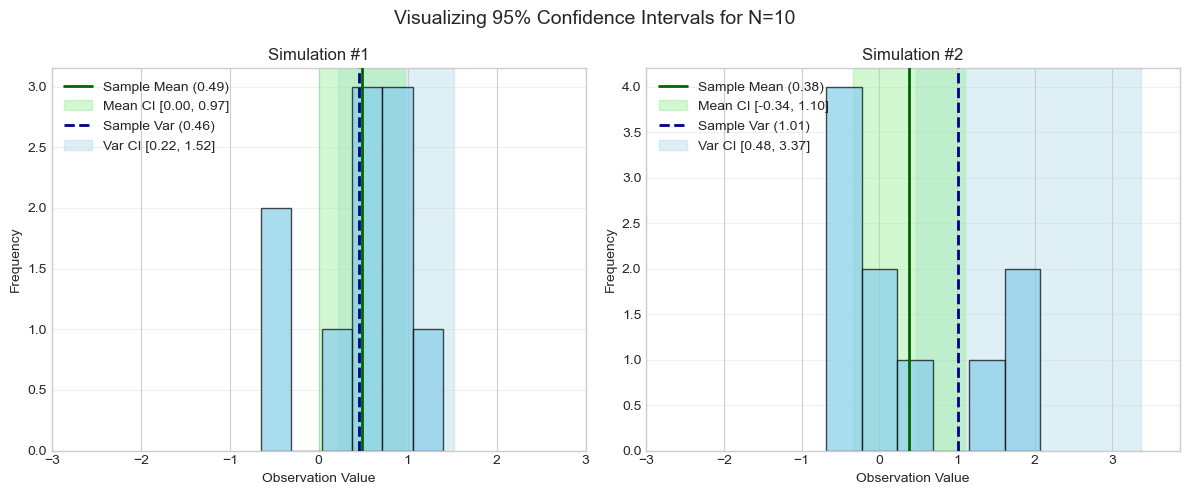

In [38]:
# Plotting the first 2 simulations
indices_to_plot = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Visualizing 95% Confidence Intervals for N=10', fontsize=14)

for ax, idx in zip(axes, indices_to_plot):
    # Extract the data for this specific simulation
    obs = samples[idx]
    m_low, m_up = mean_intervals[idx]
    v_low, v_up = var_intervals[idx]
    x_bar = np.mean(obs)
    s2 = np.var(obs, ddof=1)
    
    # Plot the histogram of the 10 observations
    ax.hist(obs, bins=6, color='skyblue', edgecolor='black', alpha=0.7, zorder=2)
    
    # Visualize the sample mean
    ax.axvline(x_bar, color='darkgreen', linestyle='-', linewidth=2, 
               label=f'Sample Mean ({x_bar:.2f})', zorder=3)
    
    # Visualize the 95% CI for the mean
    ax.axvspan(m_low, m_up, color='lightgreen', alpha=0.4, 
               label=f'Mean CI [{m_low:.2f}, {m_up:.2f}]', zorder=1)
    
    # Visualize the sample variance
    ax.axvline(s2, color='darkblue', linestyle='--', linewidth=2, 
               label=f'Sample Var ({s2:.2f})', zorder=5)
    
    # Visualize the 95% CI for the variance
    ax.axvspan(v_low, v_up, color='lightblue', alpha=0.4, 
               label=f'Var CI [{v_low:.2f}, {v_up:.2f}]', zorder=0)
    
    # Formatting the subplot
    ax.set_title(f'Simulation #{idx + 1}')
    ax.set_xlabel('Observation Value')
    ax.set_ylabel('Frequency')
    
    # Set static limits so both plots are easily comparable
    ax.set_xlim(-3, max(3, v_up + 0.5))
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Simulate from the Pareto distribution using composition.

A pareto distribution can be formed by mixing an exponential distribution with a gamma distributed rate parameter

In [40]:
def pareto_composition(k, beta_param, size=N):
    # Draw random parameter Z from a gamma distribution
    Z = np.random.gamma(shape=k, scale=1/beta_param, size=size)
    
    # Draw from exponential conditionally based on Z
    U_comp = np.random.uniform(0, 1, size)
    W = -np.log(U_comp) / Z
    
    return W + beta_param

# Simulate from it
k_test = 3.0
beta_test = 1.0

composition_sims = pareto_composition(k=k_test, beta_param=beta_test)

# Verify that it worked by checking the mean
sim_mean = np.mean(composition_sims)
theo_mean = (beta_test * k_test) / (k_test - 1)

print("Composition mehtod results:")
print(f"Sampled 10000 values using composition (k={k_test}, beta={beta_test})")
print(f"Simulated mean:    {sim_mean:.4f}")
print(f"Theoretical mean:  {theo_mean:.4f}")

Composition mehtod results:
Sampled 10000 values using composition (k=3.0, beta=1.0)
Simulated mean:    1.4970
Theoretical mean:  1.5000


# Exercise 4
Discrete event simulation program for a blocking system.

## 4.1) 

In [2]:
%pip install simpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import simpy
import random
import numpy as np
import scipy.stats as stats
import math

In [4]:
# Defining the parameters
random_seed = 2443

# System Constraints
m = 10 # numer of service units
waiting_room_capacity = 0  # No waiting room (blocking system)

# Traffic Parameters (Base case)
Mean_arrival_time = 1 # Mean time between customers
Mean_service_time = 8 # Mean service time

# Subsampling / Batching Parameters
num_batches = 10              # Number of independent sub-samples
customers_per_batch = 10000   # 10 x 10.000 customers total

In [5]:
def customer(env, server, service_time, tracker):
    
    """A customer arrives, checks for an open server, and either gets service or is blocked."""

    tracker['total_arrivals'] += 1
    
    # Check if the system is full (No waiting room)
    if server.count < server.capacity:
        # If there is room, request a server
        with server.request() as req:
            yield req # Get the server
            yield env.timeout(service_time) # Spend time being served
    else:
        # If the system is full the customer is blocked
        tracker['blocked_customers'] += 1


def arrival_process(env, server, arrival_func, service_func, tracker, total_customers):

    """Generates arriving customers over time."""

    for _ in range(total_customers):
        # Wait for the next arrival
        yield env.timeout(arrival_func())
        # Generate their service time
        service_time = service_func()
        # Start the customer process
        env.process(customer(env, server, service_time, tracker))

In [6]:
def simulate_simpy_blocking(arrival_func, service_func, m=10, batches=10, customers_per_batch=10000):

    """Runs multiple batches in SimPy to calculate the fraction of blocked customers and confidence intervals."""

    blocking_fractions = []
    
    for _ in range(batches):
        # Set up a SimPy environment for each batch
        env = simpy.Environment()
        server = simpy.Resource(env, capacity=m)
        tracker = {'total_arrivals': 0, 'blocked_customers': 0}
        
        # Start the arrival process
        env.process(arrival_process(env, server, arrival_func, service_func, tracker, customers_per_batch))
        
        # Run the simulation until all events finish
        env.run()
        
        # Record the fraction for this batch
        fraction = tracker['blocked_customers'] / tracker['total_arrivals']
        blocking_fractions.append(fraction)

    # Calculate the confidence interval
    n = len(blocking_fractions)
    sample_mean = np.mean(blocking_fractions)
    sample_variance = np.var(blocking_fractions, ddof=1)
    sample_std = np.sqrt(sample_variance)
    
    # 95% CI using t-distribution
    t_val = stats.t.ppf(0.975, df=n-1)
    margin_of_error = (sample_std / math.sqrt(n)) * t_val
    
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error
    
    return sample_mean, (ci_lower, ci_upper)

In [7]:
# The arrival process is modelled as a Poisson process
def arrival_1(): 
    # rate lambda = 1 / mean
    return random.expovariate(1.0 / Mean_arrival_time) 

# The service time is distributes as exponential
def service_1(): 
    # rate lambda = 1 / mean
    return random.expovariate(1.0 / Mean_service_time)

random.seed(2443)
np.random.seed(2443)

# Caclulating the mean and the CI
mean_1, ci_1 = simulate_simpy_blocking(
        arrival_func=arrival_1, 
        service_func=service_1, 
        m=m, 
        batches= num_batches, 
        customers_per_batch= customers_per_batch
)
    
print(f"Simulated Blocking Fraction: {mean_1:.4f} | 95% CI: [{ci_1[0]:.4f}, {ci_1[1]:.4f}]")

Simulated Blocking Fraction: 0.1207 | 95% CI: [0.1147, 0.1267]


In [8]:
# The analytical solution
def erlang_b(m, A):
    """Calculates the theoretical blocking probability using Erlang's B-formula."""
    inv_B = 1.0
    for i in range(1, m + 1):
        inv_B = 1.0 + inv_B * (i / A)
    return 1.0 / inv_B

# A is the product of the mean arrivalrate and the mean service time
analytical_sol = erlang_b(m=m, A=Mean_arrival_time*Mean_service_time)

print(f"The analytical solution is: {analytical_sol}")

The analytical solution is: 0.1216610642529515


The blocking fraction 0.1207, indicates that, on average, roughly 12.07% of arriving customers were turned away because all 10 servers were already busy. This single number is the sample mean, it was calculated by taking the average of the individual blocking fractions from the 10 independent sub-samples (the 10 batches of 10,000 customers).

By looking at how much the blocking fraction varied between the 10 batches, we can state with 95% confidence that the true theoretical blocking probability for this system lies in the found 95% CI.

Notice also that the found blocking fraction it very close to the analytical solution found using Erlangs B formula.

## 4.2)
Now the arrival process is modeled as a renewal process using the same parameters as in 4.1) whenever possible. 

We will report the fraction of blocked customers and the CI for the following two cases:

a) Erlang Distributed inter arrival times

b) Hyperexponential inter arrival times

### 4.2 a)

In [9]:
# The arrival times are Erlang distributed
# The Erlang distribution can be representedas the sum of independent exponential random variables.
# Using the procedure on slide 15/18 in day 2 (sampling fromcontinous distribution)
def arrival_2(): 
    # mean = n/lambda=1,therefore we set n=lambda=2 so 2/2=1.
    n = 2
    lambd = 2

    # Generate n independent Uniform(0, 1) variables
    # product = U_1 * U_2 * ... * U_n
    u_prod = 1.0
    for _ in range(n):
        u_prod *= random.random()

    return -(1/lambd)*np.log(u_prod)

# The service time is distributes as exponential
def service_1(): 
    # rate lambda = 1 / mean
    return random.expovariate(1.0 / Mean_service_time)

random.seed(2443)
np.random.seed(2443)

# Caclulating the mean and the CI
mean_2a, ci_2a = simulate_simpy_blocking(
        arrival_func=arrival_2, 
        service_func=service_1, 
        m=m, 
        batches= num_batches, 
        customers_per_batch= customers_per_batch
)
    
print(f"Simulated blocking fraction: {mean_2a:.4f} | 95% CI: [{ci_2a[0]:.4f}, {ci_2a[1]:.4f}]")

Simulated blocking fraction: 0.0921 | 95% CI: [0.0897, 0.0945]


Now the blocking fraction is lowerthan in 4.1

### 4.2 b)

In [10]:
def arrival_2b():
    """Hyperexponential inter-arrival times based on slide parameters."""
    if random.random() < 0.8:
        # Selected with probability p_1 = 0.8, and has the arrival rate lambda_1 = 0.8333
        return random.expovariate(0.8333)
    else:
        # Selected with probability p_2 = 0.2, and has the arrival rate lambda_2 = 5.0
        return random.expovariate(5.0)

random.seed(2443)
np.random.seed(2443)

# Caclulating the mean and the CI
mean_2b, ci_2b = simulate_simpy_blocking(
        arrival_func=arrival_2b, 
        service_func=service_1, 
        m=m, 
        batches= num_batches, 
        customers_per_batch= customers_per_batch
)
    
print(f"Simulated blocking fraction: {mean_2b:.4f} | 95% CI: [{ci_2b[0]:.4f}, {ci_2b[1]:.4f}]")

Simulated blocking fraction: 0.1385 | 95% CI: [0.1350, 0.1420]


Now the fraction is a bit higher than in 4.1

## 4.3)

Now wewill use the same arrival process as in 4.1). We will experiment with different service time distributions:

a) Constant service time

b) Pareto distributed service time

c) Choose one or two other distributions

In [11]:
# The arrival process is modelled as a Poisson process
def arrival_1(): 
    # rate lambda = 1 / mean
    return random.expovariate(1.0 / Mean_arrival_time) 

# We use the same arrival process as in 4.1) The function called arrival_1

# a) constant service time
def service_3a(): 
    # Thesercive time foreach customer is constant (the mean servicet time, 8)
    return Mean_service_time

# 3b) Pareto distributed service time with k = 1.05
def service_3b_k105():
    k = 1.05
    xm = Mean_service_time * (k - 1.0) / k
    # adding 1 and multiplying by xm to get the standard Pareto
    return (np.random.pareto(k) + 1.0) * xm

#  Pareto distribution service time with k = 2.05
def service_3b_k205():
    k = 2.05
    xm = 8.0 * (k - 1.0) / k
    return (np.random.pareto(k) + 1.0) * xm


# 3c) As another distribution I choose to look at the uniform distribution
def service_3c():
    """Uniformly distributed service times between 4 and 12 (Mean = 8)."""
    return random.uniform(4.0, 12.0)


# Running and printing the mean blocking fractions and their CI
random.seed(2443)
np.random.seed(2443)

mean_3a, ci_3a = simulate_simpy_blocking(arrival_1, service_3a, m=10, batches=10, customers_per_batch=10000)
print(f"Blocking fraction for constant: {mean_3a:.4f} | 95% CI: [{ci_3a[0]:.4f}, {ci_3a[1]:.4f}]\n")

mean_3b_1, ci_3b_1 = simulate_simpy_blocking(arrival_1, service_3b_k105, m=10, batches=10, customers_per_batch=10000)
print(f"Blocking fraction for Pareto with k=1,05: {mean_3b_1:.4f} | 95% CI: [{ci_3b_1[0]:.4f}, {ci_3b_1[1]:.4f}]\n")
    
mean_3b_2, ci_3b_2 = simulate_simpy_blocking(arrival_1, service_3b_k205, m=10, batches=10, customers_per_batch=10000)
print(f"Blocking fraction for Pareto with k=2,05: {mean_3b_2:.4f} | 95% CI: [{ci_3b_2[0]:.4f}, {ci_3b_2[1]:.4f}]\n")

mean_3c, ci_3c = simulate_simpy_blocking(arrival_1, service_3c, m=10, batches=10, customers_per_batch=10000)
print(f"Blocking fraction for Uniform: {mean_3c:.4f} | 95% CI: [{ci_3c[0]:.4f}, {ci_3c[1]:.4f}]\n")

Blocking fraction for constant: 0.1196 | 95% CI: [0.1177, 0.1215]

Blocking fraction for Pareto with k=1,05: 0.0006 | 95% CI: [0.0002, 0.0009]

Blocking fraction for Pareto with k=2,05: 0.1241 | 95% CI: [0.1207, 0.1275]

Blocking fraction for Uniform: 0.1192 | 95% CI: [0.1152, 0.1232]



We notice that the constant, the Pareto with k=2,5 and the uniform all are arount the analytical blocking fraction 12%.

# Exercise 5: Variance reduction methods

## 5-1) 
Estimate the integral by simulation using the crude Monte Carlo estimator.

Use, for example, an estimator based on 100 samples.
Present the result as both a point estimate and a confidence interval.

In [22]:
np.random.seed(2443)
# Generate 100 samples from a uniform U(0,1) distribution
n_51 = 100
U_51 = np.random.uniform(0,1,n_51)

# Define X
X_51 = np.exp(U_51)

# Computing the estimate using the crude Monto carlo estimator
X_bar_MC = np.mean(X_51)

# Finding the 95% confidence interval
standard_error = np.std(X_51, ddof=1) / np.sqrt(n_51)
ci_lower, ci_upper = stats.t.interval(confidence=0.95, df=n_51-1, loc=X_bar_MC, scale=standard_error)

print(f"Estimate using the crude Monte Carlo:   {X_bar_MC:.4f}")
print(f"95% confidence interval:               ({ci_lower:.4f}, {ci_upper:.4f})")

Estimate using the crude Monte Carlo:   1.6543
95% confidence interval:               (1.5619, 1.7467)


## 5.2
Estimate the integral using antithetic variables and comparable computational resources.

In [27]:
np.random.seed(2443)

# Generating the new random variable Y (using both exp(U) and exp(1-U))
Y_52 = (np.exp(U_51) + np.exp(1-U_51))/2

# Computing the mean
Y_bar_AV = np.mean(Y_52)

# Finding the 95% confidence interval
standard_error_52 = np.std(Y_52, ddof=1) / np.sqrt(n_51)
ci_lower_52, ci_upper_52 = stats.t.interval(confidence=0.95, df=n_51-1, loc=Y_bar_AV, scale=standard_error_52)

print(f"Estimate using Antithetic variables:    {Y_bar_AV:.4f}")
print(f"95% confidence interval:               ({ci_lower_52:.4f}, {ci_upper_52:.4f})")

Estimate using Antithetic variables:    1.7131
95% confidence interval:               (1.7009, 1.7252)


Note that the estimate is closer to the theoretical estimate and the confiddence interval is narrower.

## 5.3)
Estimate the integral using a control variate and comparable computational resources.

In [32]:
# We use U_i as a control variate with known mean E[U] = 0.5 

# The c coefficient
cov_matrix_53 = np.cov(X_51, U_51)
c = -cov_matrix_53[0, 1] / (1/12)   # 1/12 is the theoretical variance of U

# Estimate
Y_53 = X_51 + c*(U_51 - 0.5)  # 0.5 is the theoretical mean of U
Y_bar_CV = np.mean(Y_53)

# Finding the 95% confidence interval
standard_error_53 = np.std(Y_53, ddof=1) / np.sqrt(n_51)
ci_lower_53, ci_upper_53 = stats.t.interval(confidence=0.95, df=n_51-1, loc=Y_bar_CV, scale=standard_error_53)

print(f"Estimate using Control variate:        {Y_bar_CV:.4f}")
print(f"95% confidence interval:               ({ci_lower_53:.4f}, {ci_upper_53:.4f})")

Estimate using Control variate:        1.7078
95% confidence interval:               (1.6935, 1.7220)


## 5.4)
Estimate the integral using stratified sampling and comparable computational resources.

In [ ]:
np.random.seed(2443)
m = 10  # Number of regions

# Computing estimate using stratified sampling
W = np.zeros(n_51)
for i in range(n_51):
    U = np.random.uniform(0, 1, m)
    
    strata_U = (U / m) + (np.arange(m) / m)
    
    W[i] = (1/m) * np.sum(np.exp(strata_U))

# Point estimate
W_bar = np.mean(W)

# Finding the 95% confidence interval
standard_error_54 = np.std(W, ddof=1) / np.sqrt(n_51)
ci_lower_54, ci_upper_54 = stats.t.interval(confidence=0.95, df=n_51-1, loc=W_bar, scale=standard_error_54)

print(f"Estimate using stratified sampling:     {W_bar:.4f}")
print(f"95% confidence interval:               ({ci_lower_54:.4f}, {ci_upper_54:.4f})")

Estimate using Control variate:        1.7177
95% confidence interval:               (1.7144, 1.7209)


The confidence interval is even more narrow than in 5.2 (AV)

## 5.5)
Use control variates to reduce the variance of the estimator in Exercise 4 (Poisson arrivals).

In [35]:
def arrival_process_cv(env, server, arrival_func, service_func, tracker, total_customers):
    """Generates arriving customers and tracks service times for control variates."""
    for _ in range(total_customers):
        # Wait for the next arrival
        yield env.timeout(arrival_func())
        
        # Generate and track the service time 
        service_time = service_func()
        tracker['sum_service_time'] += service_time
        
        # Start the customer process
        env.process(customer(env, server, service_time, tracker))

def simulate_simpy_blocking_cv(arrival_func, service_func, expected_service_time, m=10, batches=10, customers_per_batch=10000):
    """Runs simulation using Average Service Time as a Control Variate."""
    blocking_fractions = []   # This is our X_i
    avg_service_times = []    # This is our control variate Z_i
    
    for _ in range(batches):
        env = simpy.Environment()
        server = simpy.Resource(env, capacity=m)
        tracker = {'total_arrivals': 0, 'blocked_customers': 0, 'sum_service_time': 0.0}
        
        env.process(arrival_process_cv(env, server, arrival_func, service_func, tracker, customers_per_batch))
        env.run()
        
        # Record X_i (blocking fraction)
        fraction = tracker['blocked_customers'] / tracker['total_arrivals']
        blocking_fractions.append(fraction)
        
        # Record Z_i (average service time for this batch)
        avg_service = tracker['sum_service_time'] / tracker['total_arrivals']
        avg_service_times.append(avg_service)

    # Convert to numpy arrays
    X = np.array(blocking_fractions)
    Z = np.array(avg_service_times)
    
    # Calculate c = - Cov(X, Z) / Var(Z)
    cov_matrix = np.cov(X, Z)
    c = -cov_matrix[0, 1] / np.var(Z, ddof=1)
    
    # Y_i = X_i + c(Z_i - E[Z])
    Y = X + c * (Z - expected_service_time)
    
    # Calculate the confidence interval for Y
    n = len(Y)
    Y_bar_CV = np.mean(Y)
    standard_error = np.std(Y, ddof=1) / np.sqrt(n)
    ci_lower, ci_upper = stats.t.interval(confidence=0.95, df=n-1, loc=Y_bar_CV, scale=standard_error)
    
    # We will return the variances too, just so we can see how much it improved!
    var_X = np.var(X, ddof=1)
    var_Y = np.var(Y, ddof=1)
    
    return Y_bar_CV, (ci_lower, ci_upper), var_X, var_Y

# Run the simulation
random.seed(2443)
np.random.seed(2443)

mean_cv, ci_cv, var_original, var_reduced = simulate_simpy_blocking_cv(
    arrival_func=arrival_1, 
    service_func=service_1, 
    expected_service_time=Mean_service_time, # E[Z] = 8
    m=m, 
    batches=num_batches, 
    customers_per_batch=customers_per_batch
)

print(f"Estimate using Control Variates: {mean_cv:.4f}")
print(f"95% confidence interval:        [{ci_cv[0]:.4f}, {ci_cv[1]:.4f}]")
print("-" * 40)
print(f"Original Variance (crude MC):    {var_original:.7f}")
print(f"Reduced Variance (with CV):      {var_reduced:.7f}")
print(f"Variance Reduction:              {((var_original - var_reduced) / var_original) * 100:.1f}%")

Estimate using Control Variates: 0.1190
95% confidence interval:        [0.1152, 0.1229]
----------------------------------------
Original Variance (crude MC):    0.0000707
Reduced Variance (with CV):      0.0000289
Variance Reduction:              59.2%


## 5.7)
Let Z be normally distributed with mean 0 and variance 1. 
Estimate P(Z>a) using the crude Monte Carlo estimator. Then apply importance sampling using a normal distribution with mean a and variance sigma^2.

In [40]:
# We define a function that computes estimate using crude Monte Carlo
def crude_monte_carlo(a, n):
    X = np.random.normal(0, 1, n)                 # Simulate n samples from N(0, 1)
    
    est_MC = np.mean(X > a)                       # Estimate of P(Z > a)
    
    # The variance of the estimator
    variance = (est_MC * (1 - est_MC)) / n           
    SE = np.sqrt(variance)   
    
    # 95% confidence interval
    CI_lower = est_MC - 1.96 * SE                 
    CI_upper = est_MC + 1.96 * SE
    
    return f"Estimate: {est_MC:>9.7f} | Variance: {variance:>9.2e} | CI: ({CI_lower:>10.7f}, {CI_upper:>10.7f})"

# We define a function to perform Importance Sampling
def importance_sampling(a, n, sigma2=1):
    sigma = np.sqrt(sigma2)
    
    # Simulate from proposal distribution N(a, sigma^2)
    Z = np.random.normal(a, sigma, n)
    
    # Calculate weights
    w = stats.norm.pdf(Z) / stats.norm.pdf(Z, loc=a, scale=sigma)
    
    # Indicator function
    h = (Z > a).astype(float)
    hw = h * w
    
    est_IS = np.mean(hw)
    
    # Variance of the estimator
    sample_var = np.var(hw, ddof=1)
    variance = sample_var / n
    SE = np.sqrt(variance)
    
    CI_lower = est_IS - 1.96 * SE
    CI_upper = est_IS + 1.96 * SE
    
    return f"Estimate: {est_IS:>9.7f} | Variance: {variance:>9.2e} | CI: ({CI_lower:>10.7f}, {CI_upper:>10.7f})"



# Running the Experiments
np.random.seed(2443)

# Using signa^2=1
# Using a=2 and a=4
# Using the sample sizes n=1000. n=10000, n=100000

print("Crude Monte Carlo:")
print("a=2, n=1000:   ", crude_monte_carlo(2, 1000))
print("a=4, n=1000:   ", crude_monte_carlo(4, 1000))
print("a=2, n=10000:  ", crude_monte_carlo(2, 10000))
print("a=4, n=10000:  ", crude_monte_carlo(4, 10000))
print("a=2, n=100000: ", crude_monte_carlo(2, 100000))
print("a=4, n=100000: ", crude_monte_carlo(4, 100000))

print("\nImportance Sampling (sigma^2 = 1):")
print("a=2, n=1000:   ", importance_sampling(2, 1000, sigma2=1))
print("a=4, n=1000:   ", importance_sampling(4, 1000, sigma2=1))
print("a=2, n=10000:  ", importance_sampling(2, 10000, sigma2=1))
print("a=4, n=10000:  ", importance_sampling(4, 10000, sigma2=1))
print("a=2, n=100000: ", importance_sampling(2, 100000, sigma2=1))
print("a=4, n=100000: ", importance_sampling(4, 100000, sigma2=1))

print("\nTheoretical Values:")
print("a=2:         ", stats.norm.sf(2))
print("a=4:         ", stats.norm.sf(4))

Crude Monte Carlo:
a=2, n=1000:    Estimate: 0.0240000 | Variance:  2.34e-05 | CI: ( 0.0145139,  0.0334861)
a=4, n=1000:    Estimate: 0.0000000 | Variance:  0.00e+00 | CI: ( 0.0000000,  0.0000000)
a=2, n=10000:   Estimate: 0.0223000 | Variance:  2.18e-06 | CI: ( 0.0194059,  0.0251941)
a=4, n=10000:   Estimate: 0.0000000 | Variance:  0.00e+00 | CI: ( 0.0000000,  0.0000000)
a=2, n=100000:  Estimate: 0.0231400 | Variance:  2.26e-07 | CI: ( 0.0222081,  0.0240719)
a=4, n=100000:  Estimate: 0.0000100 | Variance:  1.00e-10 | CI: (-0.0000096,  0.0000296)

Importance Sampling (sigma^2 = 1):
a=2, n=1000:    Estimate: 0.0200196 | Variance:  1.02e-06 | CI: ( 0.0180367,  0.0220026)
a=4, n=1000:    Estimate: 0.0000312 | Variance:  4.46e-12 | CI: ( 0.0000270,  0.0000353)
a=2, n=10000:   Estimate: 0.0225120 | Variance:  1.20e-07 | CI: ( 0.0218344,  0.0231896)
a=4, n=10000:   Estimate: 0.0000316 | Variance:  4.49e-13 | CI: ( 0.0000303,  0.0000329)
a=2, n=100000:  Estimate: 0.0229958 | Variance:  1.23e-

The CI for a=4, n=100000 demonstrates that large sample sizes do not automatically guarantee accurate estimates if important regions of the distribution are sampled only rarely. Because negative values are in the CI.

## 5.8)

In [45]:
def importance_sampling_exp(lmbda, n):
    # Sample from the exponential distribution
    Y = np.random.exponential(1/lmbda, n)
    
    # We only care about samples that are in the interval [0, 1]
    valid_mask = (Y >= 0) & (Y <= 1)
    
    # Calculate weights W = (h(x)*f(x)) / g(x)
    weights = np.zeros(n)   # If Y is outside [0,1], the weight is 0
    weights[valid_mask] = np.exp(Y[valid_mask]) / (lmbda * np.exp(-lmbda * Y[valid_mask]))
    
    est = np.mean(weights)
    var = np.var(weights, ddof=1)
    
    return est, var

# Running the simulation
np.random.seed(2443)
n_samples = 10000

print(f"{'Lambda':<10} | {'Estimate':<10} | {'Variance':<10}")
print("-" * 35)

# Testing various lambdas, including the theoretical optimum 1.414
lambdas = [0.5, 1.0, 1.414, 2.0, 3.0]

for l in lambdas:
    est, var = importance_sampling_exp(lmbda=l, n=n_samples)
    print(f"{l:<10.3f} | {est:<10.5f} | {var:<10.5f}")

print("-" * 35)
# The theoretical variance of the crude Monte Carlo estimator
theoretical_var = ((np.exp(2) - 1) / 2) - (np.exp(1) - 1)**2
print(f"Crude Monte Carlo variance (from 5.1): {theoretical_var:.5f}")


Lambda     | Estimate   | Variance  
-----------------------------------
0.500      | 1.67160    | 5.82306   
1.000      | 1.72828    | 3.41694   
1.414      | 1.73299    | 3.17747   
2.000      | 1.72920    | 3.84880   
3.000      | 1.74115    | 7.06548   
-----------------------------------
Crude Monte Carlo variance (from 5.1): 0.24204


# Exercise 6: Markov Chain Monte Carlo

In [1]:
import numpy as np
import math
from scipy.stats import chisquare
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

## 6.1) 
Generating values from a truncated Poisson distribution by applying the Metropolis-Hastings algorithm, and verifying with a Chi-square test

In [2]:
# Define parameters (from exercise 4)
A = 8
m = 10
N = 100000
burn_in = N // 2       # States to discard at the start

np.random.seed(4223)


# Define the unnormalized target distribution
def g(i):
    if i < 0 or i > m:  # for i=0,...,m
        return 0.0
    return (A**i) / math.factorial(i)


# Run Metropolis Hastings
samples = []    # Initilize an empty list to store the samples in
current_state = 0   # Initial state

for _ in range(N):
    # Propose a candidate state (Random walk: +1 or -1)
    step = np.random.choice([-1, 1])
    proposed_state = current_state + step
    
    # Calculate acceptance probability
    if proposed_state < 0 or proposed_state > m:   # If outside the bounds
        alpha = 0.0 # Reject out of bounds proposals
    else:
        alpha = min(1.0, g(proposed_state) / g(current_state))  # accept with probability g(y)/g(x)
        
    # Accept or reject
    u = np.random.rand()    # Random number between 0 and 1
    if u < alpha:
        current_state = proposed_state # Accept move
        
    # Appent the new state
    samples.append(current_state)

# Discard the burn-in period
valid_samples = samples[burn_in:]


In [3]:
# Calculate observed frequencies from MCMC
observed_counts = np.zeros(m + 1)   # The Poisson system can take values from 0 to m
for sample in valid_samples:    # Loops though every visited state of the Markov chain
    observed_counts[sample] += 1

# Calculate exact theoretical probabilities
g_unnormalized = [g(i) for i in range(m + 1)]
c = 1.0 / sum(g_unnormalized) # The normalizing constant (the probabilities must sum to 1)
theoretical_probs = [c * val for val in g_unnormalized]

# Calculate expected frequencies
expected_counts = np.array(theoretical_probs) * len(valid_samples)

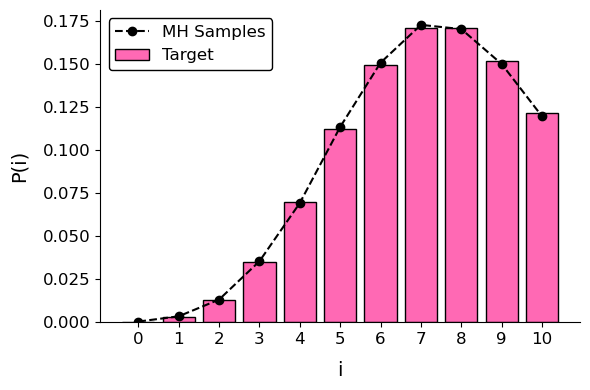

In [4]:
# Plotting the true distribution and the samples

# Convert the raw counts from the MCMC simulation into probabilities
mh_probs = observed_counts / len(valid_samples)

# The range of the x-axis
x_vals = np.arange(m + 1)

# Create the plot
plt.figure(figsize=(6, 4))

# Plotingt the target theoretical distribution as a histogram
plt.bar(x_vals, theoretical_probs, color='hotpink', edgecolor='black', label='Target')

# Plot the samples as a line with markers
plt.plot(x_vals, mh_probs, color='black', marker='o', linestyle='--', label='MH Samples')

# Formatting the plot
plt.xlabel('i', fontsize=14, labelpad=10)
plt.ylabel('P(i)', fontsize=14, labelpad=10)

plt.xticks(x_vals, fontsize=12) 
plt.yticks(fontsize=12)

# Add the legend in the top left corner
plt.legend(fontsize=12, loc='upper left', framealpha=1, edgecolor='black')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display the plot
plt.tight_layout()
plt.show()

The plot indicates that the fit is quite good. 

The Chi-square test assumes that all samples are independent. However, samples generated via MCMC are autocorrelated (each state depends on the previous one). To perform a valid statistical test, we therefore first thin the chain to obtain independent samples. We start by plotting the ACF to see how many samples to thin out.

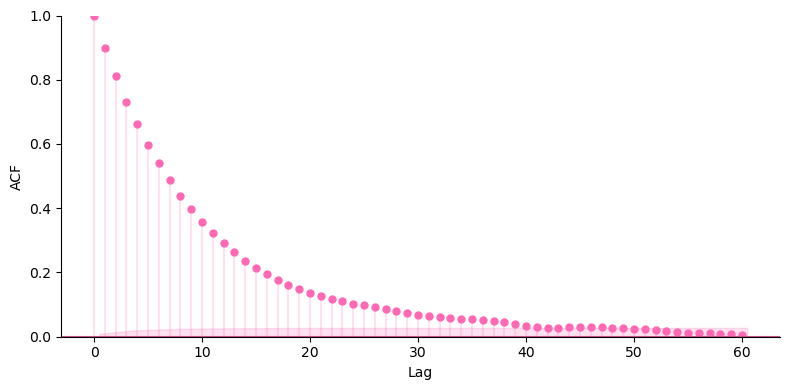

In [5]:
# Plot the autocorrelation function (ACF)
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(valid_samples, lags=60, ax=ax, alpha=0.05)

# Change colors
for line in ax.lines:
    line.set_color("hotpink")

for collection in ax.collections:
    collection.set_color("hotpink")
    collection.set_alpha(0.2)

ax.set_title("")
plt.xlabel("Lag")
plt.ylabel("ACF")

# Add a horizontal line at 0 for easy reading
plt.axhline(0, color='black', linewidth=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# No need to show the negative y-axis
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

The plot shows the autocorrelation for the MCMC samples. Wee see thay they come inside the confidence interval at lag 50, therefore we thin by taking only every 50 sample

In [6]:
# Thin the samples to remove autocorrelation 
thin_interval = 50  # Keep only 1 out of every 50 samples
thinned_samples = valid_samples[::thin_interval] 

print(f"Original valid samples: {len(valid_samples)}")
print(f"Thinned independent samples for testing: {len(thinned_samples)}")

# Calculate observed frequencies from the thinned MCMC
observed_counts = np.zeros(m + 1)
for sample in thinned_samples:
    observed_counts[sample] += 1

# Calculate exact theoretical probabilities
g_unnormalized = [g(i) for i in range(m + 1)]
c = 1.0 / sum(g_unnormalized) 
theoretical_probs = [c * val for val in g_unnormalized]

# Calculate expected frequencies using the thinned length
expected_counts = np.array(theoretical_probs) * len(thinned_samples)

# Perform the Chi-square test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi^2 Statistic with thinning: {chi2_stat:.4f}")
print(f"p-value with thinning:        {p_value:.4f}")

Original valid samples: 50000
Thinned independent samples for testing: 1000
Chi^2 Statistic with thinning: 7.9973
p-value with thinning:        0.6291


## 6.2

In [7]:
# Defining new parameters
A_1 = A_2 = 4
m = 10

# Defining the new unnormalized target distribution
def g(i):
    if i < 0 or i > m:  # for i=0,...,m
        return 0.0
    return (A**i) / math.factorial(i)

In [8]:
np.random.seed(4223)

# Defining the parameters
A1 = 4
A2 = 4
m = 10
N = 100000
burn_in = N // 2
thin_interval = 50  # Conservative thinning for 2D space

# Define the unnormalized 2D target distribution
def g2(i, j):
    if i < 0 or j < 0 or i + j > m: # Enforce the constraint: 0 <= i+j >= 10
        return 0.0
    return ((A1**i) / math.factorial(i)) * ((A2**j) / math.factorial(j))


In [9]:
# a) Defining a function to use Metropolis-Hastings directly 
def mh_direct(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    dirs = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]]) # Up, right, down, left
    
    for k in range(N):
        prop = curr + dirs[np.random.choice(4)]
        alpha = min(1, g2(prop[0], prop[1]) / g2(curr[0], curr[1]))   # If g2(curr) is 0, alpha is 0
        if np.random.rand() < alpha:
            curr = prop # move to the new position
        samples[k] = curr.copy()
    return samples

In [10]:
# b) Defining a function to use Metropolis-Hastings coordinate wise
def mh_coordinate(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    
    for k in range(N):
        # Updating i (coordinate 1)
        prop_i = curr[0] + np.random.choice([-1, 1])
        alpha_i = min(1, g2(prop_i, curr[1]) / g2(curr[0], curr[1]))
        if np.random.rand() < alpha_i: 
            curr[0] = prop_i
            
        # Updating j (coordinate 2)
        prop_j = curr[1] + np.random.choice([-1, 1])
        alpha_j = min(1, g2(curr[0], prop_j) / g2(curr[0], curr[1]))
        if np.random.rand() < alpha_j: 
            curr[1] = prop_j
            
        samples[k] = curr.copy()
    return samples

In [11]:
# c) defining a function to use Gibbs sampling 
def gibbs_sampling(start_state):
    samples = np.zeros((N, 2), dtype=int)
    curr = np.array(start_state)
    
    for k in range(N):
        # Sample i given j
        max_i = m - curr[1]     # to culfull the constraint: 0 <= i+j >= m
        probs_i = np.array([(A1**i) / math.factorial(i) for i in range(max_i + 1)]) # the unnormalized probabilities for every valid state of i
        probs_i /= probs_i.sum() # Normalize
        curr[0] = np.random.choice(range(max_i + 1), p=probs_i)
        
        # Sample j given i
        max_j = m - curr[0]
        probs_j = np.array([(A2**j) / math.factorial(j) for j in range(max_j + 1)])
        probs_j /= probs_j.sum() # Normalize
        curr[1] = np.random.choice(range(max_j + 1), p=probs_j)
        
        # store the new coordinates
        samples[k] = curr.copy()
    return samples

In [12]:
# Generating samples (without thinning)
np.random.seed(2443)
start = [3, 3]  # Choosing a starting point
samples_dir_raw = mh_direct(start)[burn_in:]
samples_coor_raw = mh_coordinate(start)[burn_in:]
samples_gibbs_raw = gibbs_sampling(start)[burn_in:]

Plotting the theoretical target and the samples as heatmaps

In [13]:
# Calculate The theoretical probabilities
prop_theo = np.zeros((m + 1, m + 1))
for i in range(m + 1):
    for j in range(m + 1 - i):
        prop_theo[i, j] = g2(i, j)
prop_theo /= np.sum(prop_theo) # Normalize

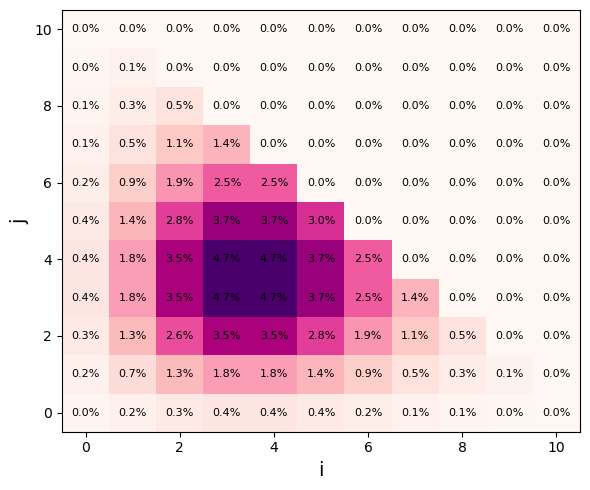

In [14]:
# Plot the theoretical target
plt.figure(figsize=(6, 5))
plt.imshow(prop_theo.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages to the states
for i in range(m + 1):
    for j in range(m + 1):
        val = prop_theo[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black' if val < 10 else 'white', fontsize=8)

plt.xlabel('i', fontsize=14)
plt.ylabel('j', fontsize=14)
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

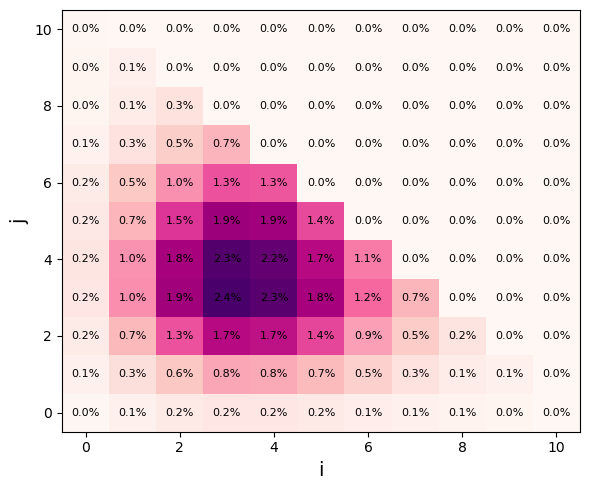

In [15]:
# Heatmap for the samples from the direct MH
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_dir_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)   # Divide the raw counts by the total number of samples to get the probability

plt.figure(figsize=(6, 5))
# Drawing the heatmap
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')   # .T transposes the matrix so 'i' is the x-axis and 'j' is the y-axis

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100   # Convert the decimal probability to a percentage format
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

# Layout formatting
plt.xlabel('i', fontsize=14)
plt.ylabel('j', fontsize=14)
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

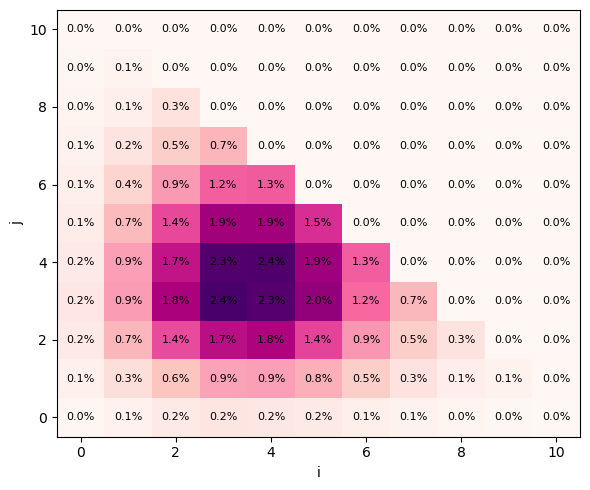

In [16]:
# Heatmap for the samples from the coordinatewise MH
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_coor_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)

plt.figure(figsize=(6, 5))
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

plt.xlabel('i')
plt.ylabel('j')
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

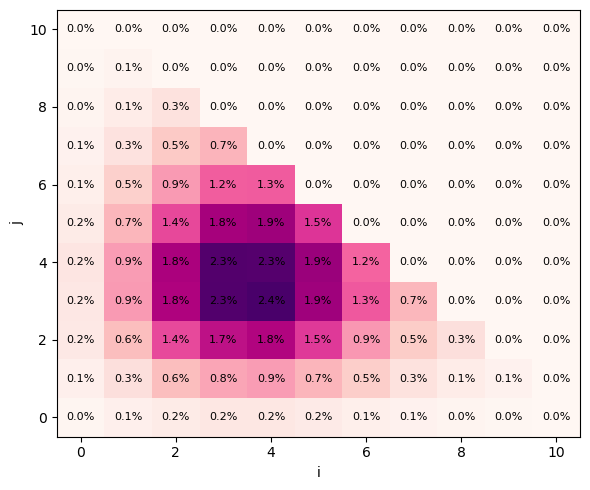

In [17]:
# Heatmap for the samples from the Gibbs method
obs_freq = np.zeros((m + 1, m + 1))
for i, j in samples_gibbs_raw:
    obs_freq[i, j] += 1
        
# Convert counts to percentages
empirical_probs = obs_freq / len(samples)

plt.figure(figsize=(6, 5))
plt.imshow(empirical_probs.T, origin='lower', cmap='RdPu', aspect='auto')

# Add text percentages
for i in range(m + 1):
    for j in range(m + 1):
        val = empirical_probs[i, j] * 100
        plt.text(i, j, f"{val:.1f}%", ha='center', va='center', 
                    color='black', fontsize=8)

plt.xlabel('i')
plt.ylabel('j')
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

To make the Chi-square test we again plot the ACF for the MH functions to see when they are no longer significantly dependent

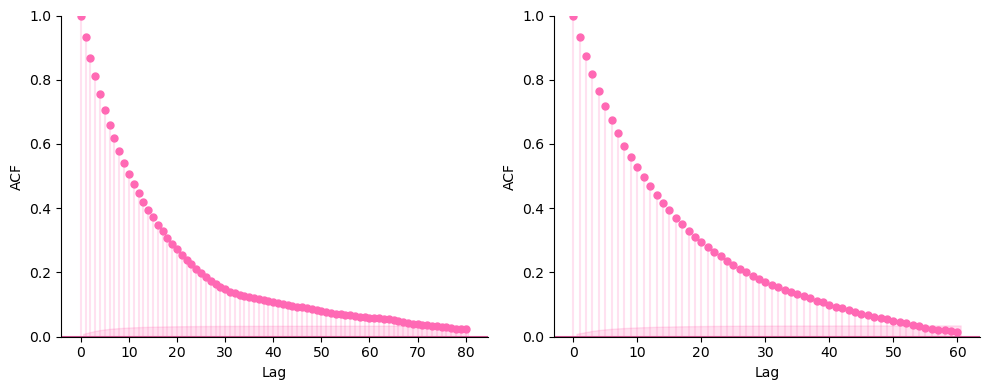

In [18]:
# The ACF for the direct MH method
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot ACF for coordinate i on the left subplot (ax[0])
plot_acf(samples_dir_raw[:, 0], lags=80, ax=ax[0], alpha=0.05)

# Plot ACF for coordinate j on the right subplot (ax[1])
plot_acf(samples_dir_raw[:, 1], lags=60, ax=ax[1], alpha=0.05)

for current_ax in ax:
    for line in current_ax.lines:
        line.set_color("hotpink")
    for collection in current_ax.collections:
        collection.set_color("hotpink")
        collection.set_alpha(0.2)

    # Formatting
    current_ax.set_title("")
    current_ax.set_xlabel("Lag")
    current_ax.set_ylabel("ACF")
    current_ax.axhline(0, color='black', linewidth=1)
    
    current_ax.spines['top'].set_visible(False)
    current_ax.spines['right'].set_visible(False)
    
    # No need to show the negative y-axis
    current_ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Looks like both coordinates are inside the confidence interval at about lag 70, so we will be thinning by using every 70th samplefor the direct method.

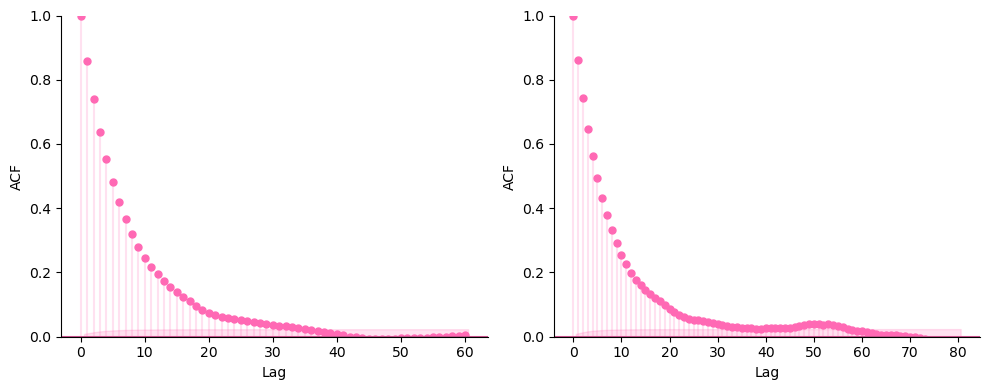

In [19]:
# The ACF for the coordinate wise MH
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot ACF for coordinate i on the left subplot (ax[0])
plot_acf(samples_coor_raw[:, 0], lags=60, ax=ax[0], alpha=0.05)

# Plot ACF for coordinate j on the right subplot (ax[1])
plot_acf(samples_coor_raw[:, 1], lags=80, ax=ax[1], alpha=0.05)

for current_ax in ax:
    for line in current_ax.lines:
        line.set_color("hotpink")
    for collection in current_ax.collections:
        collection.set_color("hotpink")
        collection.set_alpha(0.2)

    # Formatting
    current_ax.set_title("")
    current_ax.set_xlabel("Lag")
    current_ax.set_ylabel("ACF")
    current_ax.axhline(0, color='black', linewidth=1)
    
    current_ax.spines['top'].set_visible(False)
    current_ax.spines['right'].set_visible(False)
    
    # No need to show the negative y-axis
    current_ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Looks like both coordinates are inside the confidence interval after lag 60 for the coordinatewise MH.

In [20]:
# We thin the samples to remove autocorrelation 
samples_dir_test = samples_dir_raw[::70]  # Keep only 1 out of every 70 samples

samples_coor_test = samples_coor_raw[::60]  # Keep only 1 out of every 60 samples

# In Gibbs we do not thin (we use all the samples)
samples_gibbs_test = samples_gibbs_raw[::1] 


# Define a helper function
def run_chi2_test(samples, name):
    print(f"Chi-square test for the method: {name}")
    print(f"Samples used for test: {len(samples)}")
    
    # Observed frequencies
    obs_freq = np.zeros((m + 1, m + 1))
    for i, j in samples:
        obs_freq[i, j] += 1
        
    # We flatten the 2D grid into a 1D array
    obs_flat = obs_freq.flatten()
    exp_flat = (prop_theo * len(samples)).flatten() # Expected count for every state

    valid_mask = exp_flat > 0   # We only test states where the expected probability is > 0
    obs_valid = obs_flat[valid_mask]
    exp_valid = exp_flat[valid_mask]
    
    # Run the test
    chi2_stat, p_val = chisquare(f_obs=obs_valid, f_exp=exp_valid)
    
    print(f"Chi2 Statistic: {chi2_stat:.4f}")
    print(f"P-value:        {p_val:.4f}\n")


# Run the Chi-square test for the three methods
run_chi2_test(samples_dir_test, "Direct Metropolis Hastings")
run_chi2_test(samples_coor_test, "Coordinate wise Metropolis Hastings")
run_chi2_test(samples_gibbs_test, "Gibbs Sampling")

Chi-square test for the method: Direct Metropolis Hastings
Samples used for test: 715
Chi2 Statistic: 68.5024
P-value:        0.3594

Chi-square test for the method: Coordinate wise Metropolis Hastings
Samples used for test: 834
Chi2 Statistic: 57.6965
P-value:        0.7281

Chi-square test for the method: Gibbs Sampling
Samples used for test: 50000
Chi2 Statistic: 59.4716
P-value:        0.6702



We notice that all the p-values are above 0,05 and therefore the null-hypotesis can not be rejected.

## 6.3)
Bayesian statistical problem

### 6.3 a) Generating parameters from the prior distribution

In [21]:
np.random.seed(4223)

# a)
# The prior of (Xi, Gamma) is standard normal with correlation rho = 0,5
mu_prior = [0, 0]   # mean is 0
cov_matrix = [[1.0, 0.5],   # Variance is 1, correlation is 0,5
              [0.5, 1.0]]

# Generating the pair (xi, gamma)
xi, gamma = np.random.multivariate_normal(mu_prior, cov_matrix)

# Transforming to (Theta, Psi) by taking the exponent (since its log)
theta_true = np.exp(xi)
psi_true = np.exp(gamma)

print(f"True Theta:     {theta_true:.4f}")
print(f"True Psi:       {psi_true:.4f}")

True Theta:     1.4085
True Psi:       2.6608


### 6.3 b)
Generate $X_i = 1, . . . , n$ with the values of $(\theta, \psi)$ we obtained in 6.3 a). Use $n=10$.

In [22]:
# We generate n=10 observations from N(Theta, Psi)
n = 10

X_obs = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)

# Printing the observations
print(np.round(X_obs, 4))

[-0.1392  0.6642 -0.7608 -0.7298  1.3888 -0.8054  0.0903  0.5097  0.0804
  2.1269]


### 6.3 d) + e)
Generate MCMC samples from the posterior distribution of $(\theta, \psi)$ using the Metropolis Hastings method. For this we use the log-posterior since it is better for large samples. For n= 100, 1000.

True Theta: 1.4085
True Psi:   2.6608

n =   10 | Acceptance Rate: 48.5%
n =  100 | Acceptance Rate: 22.0%
n = 1000 | Acceptance Rate: 4.3%


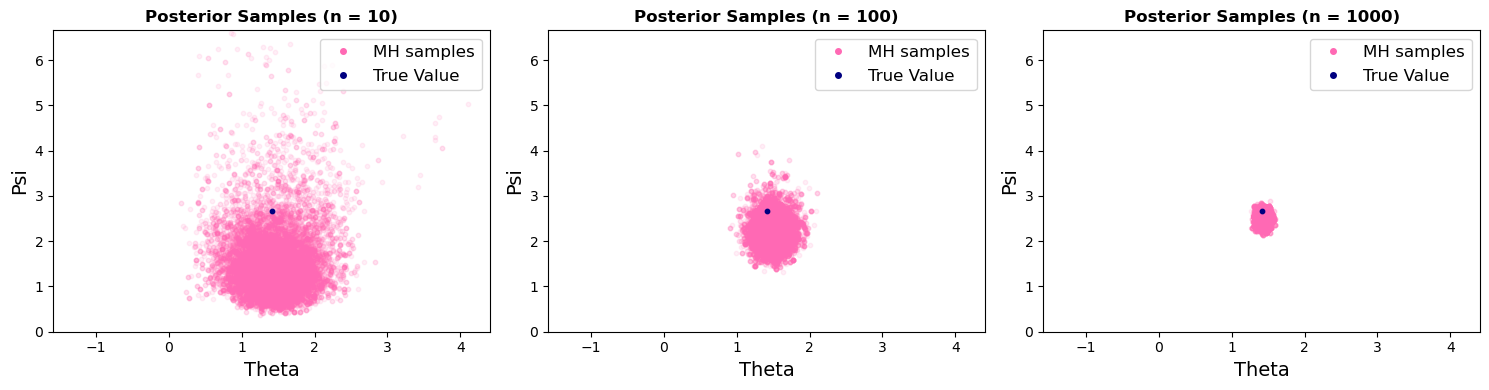

In [34]:
# Define the log-posterior
def log_posterior(theta, psi, n, x_bar, s_sq):
    if theta <= 0 or psi <= 0:  # Theta and Psi must be positive (since they are e^x).
        return -np.inf  # If negative, the probability is 0 (log is -infinity)
    
    term1 = -(n / 2 + 1) * np.log(psi)
    term2 = -np.log(theta)
    term3 = -(np.log(theta)**2 - np.log(theta)*np.log(psi) + np.log(psi)**2) / 1.5
    term4 = -((n - 1) * s_sq + n * (x_bar - theta)**2) / (2 * psi)
    
    return term1 + term2 + term3 + term4

# The Metropolis-Hastings algorithm
def run_mh(n_obs, theta_true, psi_true, num_samples=20000, step_size=0.5):
    # Generate the observations for this specific 'n'
    np.random.seed(4223 + n_obs) # changing the seed sligthly so datasets are unique
    X_obs = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n_obs)
    
    # Calculate mean and variance
    x_bar = np.mean(X_obs)
    s_sq = np.var(X_obs, ddof=1)
    if n_obs == 1: s_sq = 0 # Handle edge case if n=1
    
    # Initialize the chain
    chain = np.zeros((num_samples, 2))
    
    # Start at the sample mean and sample variance
    curr_theta = x_bar
    curr_psi = s_sq if s_sq > 0 else 1.0 
    curr_log_p = log_posterior(curr_theta, curr_psi, n_obs, x_bar, s_sq)
    
    accepted = 0
    
    for i in range(num_samples):
        # Propose a new state using a random walk (Normal distribution)
        prop_theta = np.random.normal(curr_theta, step_size)
        prop_psi = np.random.normal(curr_psi, step_size)
        
        prop_log_p = log_posterior(prop_theta, prop_psi, n_obs, x_bar, s_sq)
        
        # Calculate acceptance probability in log-scale
        log_alpha = prop_log_p - curr_log_p
        
        # Accept or reject
        if np.log(np.random.rand()) < log_alpha:
            curr_theta = prop_theta
            curr_psi = prop_psi
            curr_log_p = prop_log_p
            accepted += 1
            
        chain[i] = [curr_theta, curr_psi]
        
    print(f"n = {n_obs:4d} | Acceptance Rate: {accepted/num_samples * 100:.1f}%")
    return chain

# Printing the parameter values
print(f"True Theta: {theta_true:.4f}")
print(f"True Psi:   {psi_true:.4f}\n")

# Run the simulations (ignoring the first 20% as burn-in)
burn_in_63=4000
chain_10 = run_mh(10, theta_true, psi_true)[burn_in_63:]
chain_100 = run_mh(100, theta_true, psi_true)[burn_in_63:]
chain_1000 = run_mh(1000, theta_true, psi_true)[burn_in_63:]

from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Function to plot a 2D scatter of the samples
def plot_chain(ax, chain, n_val):
    # The samples
    ax.scatter(chain[:, 0], chain[:, 1], alpha=0.1, color='hotpink', s=10, label='MH samples')
    
    # The true values marked as navy blue points
    ax.scatter(theta_true, psi_true, color='navy', s=10, zorder=5, label='True Value')
    
    ax.set_title(f"Posterior Samples (n = {n_val})", fontweight='bold')
    ax.set_xlabel('Theta', fontsize=14)
    ax.set_ylabel('Psi', fontsize=14)
    
    # Setting the axis
    ax.set_xlim(theta_true - 3, theta_true + 3)
    ax.set_ylim(max(0, psi_true - 4), psi_true + 4)

    # Formatting the legends
    legend_handles = [
        Line2D([], [], marker='o', linestyle='None',
            color='hotpink', markersize=4,
            label='MH samples'),
        Line2D([], [], marker='o', linestyle='None',
            color='navy', markersize=4,
            label='True Value')
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=12)

plot_chain(axes[0], chain_10, 10)
plot_chain(axes[1], chain_100, 100)
plot_chain(axes[2], chain_1000, 1000)

plt.tight_layout()
plt.show()

# Exercise 7
Implementing the simulated annealing algorithm to solve the travelling salesman problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

## 7. 1)
In this part, we select $n$ points in a plane and use the Euclidean distance as our cost function. We will generate proposals by swapping two randomly selected points and use the cooling scheme $T_k = \frac{1}{\sqrt{1+k}}$. To sanity check the algorithm, we will place the points perfectly on a circle.

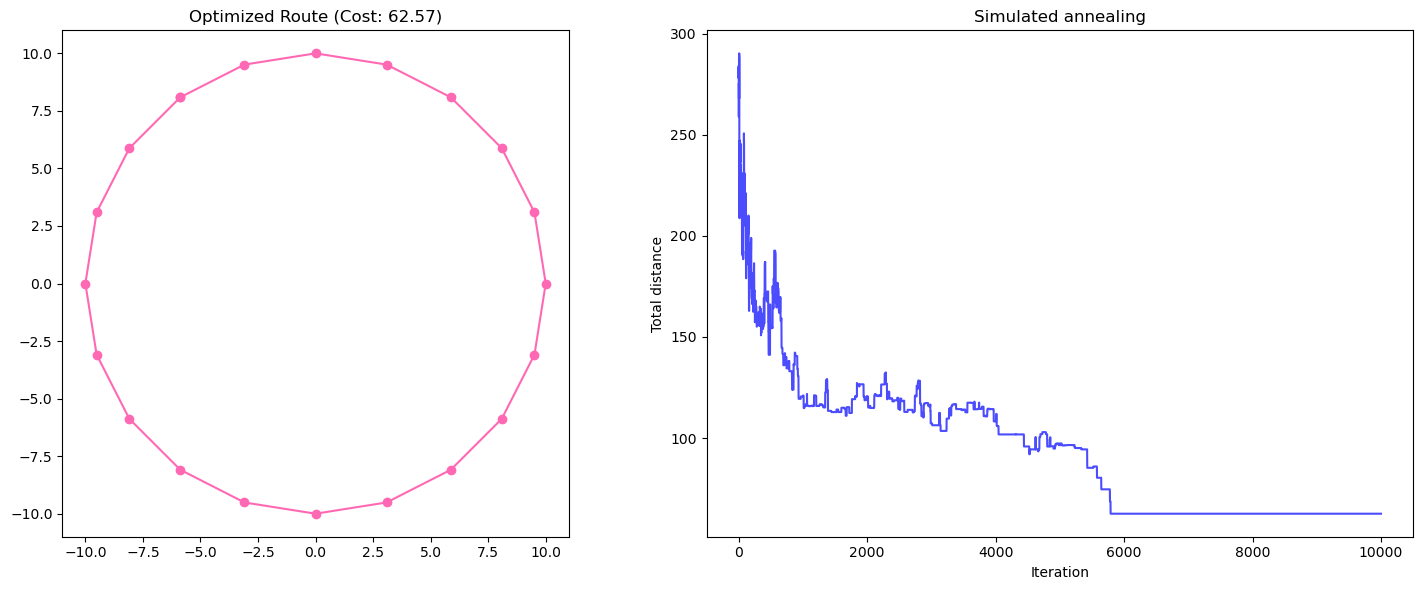

In [ ]:
# Set seeds for reproducibility
np.random.seed(2443)
random.seed(2443)

# Generate sanity check data (points on a circle)
def generate_circle_points(n, radius=10):
    """Generates n points evenly spaced on a circle."""
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.column_stack((x, y))

# Cost function
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def route_cost(route, points):
    """Calculates total Euclidean distance of the route."""
    total_dist = 0
    n = len(route)
    for i in range(n - 1):
        total_dist += euclidean_distance(points[route[i]], points[route[i+1]])
    # Add distance to return to the starting city
    total_dist += euclidean_distance(points[route[-1]], points[route[0]])
    return total_dist

# Function to generate proposals by swapping two randomly selected points on the route
def propose_swap(route):
    """Proposes a new route by swapping two cities."""
    new_route = route.copy()
    idx1, idx2 = random.sample(range(len(route)), 2)
    new_route[idx1], new_route[idx2] = new_route[idx2], new_route[idx1]
    return new_route

# The simulated annealing algorithm
def simulated_annealing_euclidean(points, max_iterations=5000):
    n = len(points)
    # Initial state: random permutation
    current_route = list(range(n))
    random.shuffle(current_route)
    current_cost = route_cost(current_route, points)
    
    # Track the best route
    best_route = current_route.copy()
    best_cost = current_cost
    
    cost_history = [current_cost]   # storing the costs in a list
    
    for k in range(1, max_iterations + 1):
        # Cooling scheme
        T_k = 100 / np.sqrt(1 + k)  # making the nominator 100, so the temperature decrease more gradually (since with the numenator 1, we did not recieve the optimal route)
        
        # Generate candidate
        candidate_route = propose_swap(current_route)
        candidate_cost = route_cost(candidate_route, points)
        
        # Acceptance logic
        delta_f = candidate_cost - current_cost
        if delta_f <= 0:
            current_route = candidate_route
            current_cost = candidate_cost
            if candidate_cost < best_cost:
                best_route = candidate_route
                best_cost = candidate_cost
        else:
            # Accept with probability exp(-delta / T)
            acceptance_prob = math.exp(-delta_f / T_k)
            if random.random() < acceptance_prob:
                current_route = candidate_route
                current_cost = candidate_cost
                
        cost_history.append(current_cost)
        
    return best_route, best_cost, cost_history

# Running the code
n_points = 20   #Choosing to use 20 points
points = generate_circle_points(n_points)

best_route, best_cost, history = simulated_annealing_euclidean(points, max_iterations=10000)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the route
ordered_points = points[best_route + [best_route[0]]] # Append start point to close loop
ax1.plot(ordered_points[:, 0], ordered_points[:, 1], marker='o', linestyle='-', color='hotpink')
ax1.set_title(f"Optimized Route (Cost: {best_cost:.2f})")
ax1.set_aspect('equal')

# Plot the convergence
ax2.plot(history, color='blue', alpha=0.7)
ax2.set_title("Simulated annealing")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Total distance")

plt.tight_layout()
plt.show()

## 7.2)
Here, we modify the program to handle general travel costs.

In [7]:
# Reading in the cost matrix
cost_matrix = np.loadtxt("cost.csv", delimiter=",")

Optimal Route Found: [18, 19, 2, 10, 7, 4, 15, 9, 8, 1, 13, 11, 5, 16, 6, 17, 3, 0, 12, 14] -> 18
Optimal Cost: 1335.0


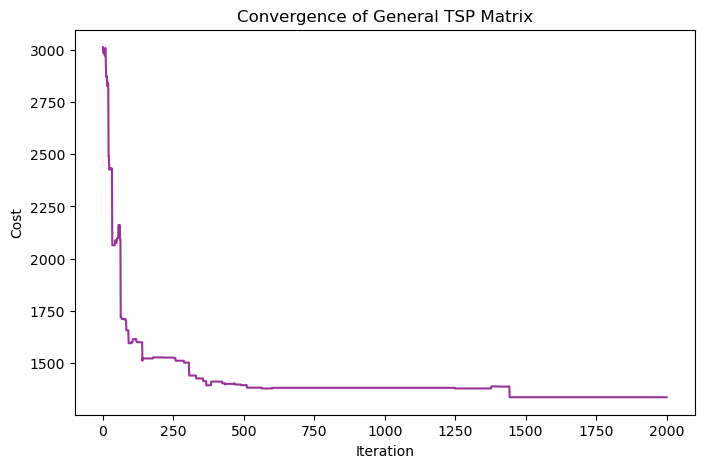

In [11]:
# Set seeds for reproducibility
np.random.seed(2443)
random.seed(2443)

# General cost function
def general_route_cost(route, matrix):
    """Calculates cost based on the adjacency matrix."""
    total_cost = 0
    n = len(route)
    for i in range(n - 1):
        total_cost += matrix[route[i], route[i+1]]
    total_cost += matrix[route[-1], route[0]] # Return trip
    return total_cost

# Simulated annealing for general costs
def simulated_annealing_general(matrix, max_iterations=5000):
    n = matrix.shape[0]
    current_route = list(range(n))
    random.shuffle(current_route)
    current_cost = general_route_cost(current_route, matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost
    cost_history = [current_cost]
    
    for k in range(1, max_iterations + 1):
        T_k = 100 / np.sqrt(1 + k)  # Cooling 
        
        candidate_route = propose_swap(current_route)
        candidate_cost = general_route_cost(candidate_route, matrix)
        
        delta_f = candidate_cost - current_cost
        
        if delta_f <= 0 or random.random() < math.exp(-delta_f / T_k):
            current_route = candidate_route
            current_cost = candidate_cost
            if candidate_cost < best_cost:
                best_route = candidate_route
                best_cost = candidate_cost
                
        cost_history.append(current_cost)
        
    return best_route, best_cost, cost_history

# Running the function
best_route_gen, best_cost_gen, history_gen = simulated_annealing_general(cost_matrix, max_iterations=2000)

readable_route = [city for city in best_route_gen]

print(f"Optimal Route Found: {readable_route} -> {readable_route[0]}")
print(f"Optimal Cost: {best_cost_gen}")

plt.figure(figsize=(8, 5))
plt.plot(history_gen, color='purple', alpha=0.8)
plt.title("Convergence of General TSP Matrix")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

# Exercise 8: Bootstrapping

## 8.1 (exercise 13 in Roos) 
### 8.1 b)

In [18]:
# Defining the data
X_81 = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
n_81 = len(X_81)
a = -5
b = 5
B = 1000 # Number of bootstrap replicates

# The mean of our empirical distribution is the sample mean
mu_hat = np.mean(X_81)

# Generating B bootstrap samples
boot_samples_81 = np.random.choice(X_81, size=(B, n_81), replace=True)

# Calculate the mean of each bootstrap sample
boot_means_81 = np.mean(boot_samples_81, axis=1)

# Check the condition in p for each sample
condition_met = (boot_means_81 - mu_hat > a) & (boot_means_81 - mu_hat < b) # True or false

# The estimated probability is the mean of the boolean array
p_estimate = np.mean(condition_met) # True gives 1 and false gives 0. Counts how many times the condition was satisfied

print(f"Original sample mean: {mu_hat:.2f}")
print(f"Estimated p: {p_estimate:.4f}")

Original sample mean: 76.70
Estimated p: 0.7420


## 8.2 (Exercise 15 in Ross)
We have 15 data points and want to estimate the variance of the sample variance.

In [19]:
# Defining the data
X_82 = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])
n_82 = len(X_82)

# Generate bootstrap samples
boot_samples_82 = np.random.choice(X_82, size=(B, n_82), replace=True)

# Calculate the sample variance for each bootstrap sample
boot_var_82 = np.var(boot_samples_82, axis=1, ddof=1)  # ddof=1 ensures we divide by (n-1) to get unbiased sample variance

# The bootstrap estimate of the variance is the sample variance of our bootstrap estimates
var_estimate_82 = np.var(boot_var_82, ddof=1)

print(f"Bootstrap Estimate of Var(S^2): {var_estimate_82:.4f}")

Bootstrap Estimate of Var(S^2): 58.8813


## 8.3)
Writing a program to evaluate the sample mean vs. the sample median for a Pareto distribution using 100 bootstrap replicates

Theoretical mean: 21.0000
Theoretical median: 1.9351
Original sample mean: 6.0122
Original sample median: 1.8396

Bootstrap variance of the mean: 2.7935
Bootstrap variance of the median: 0.0093


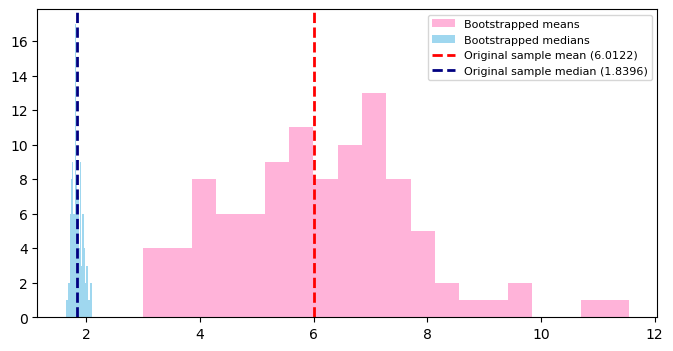

In [45]:
np.random.seed(2443)

# Defining the parameters
n_83 = 200  # Number of samples
k_83 = 1.05 # The k parameter in the pareto distribution
beta_83 = 1.0   # The beta parameter in the pareto distribution
k_boot = 100 # bootstrap replicates

# Generate Pareto data 
# To get a standard Pareto starting at beta we add 1 and multiply by beta.
pareto_data = (np.random.pareto(k_83, n_83) + 1) * beta_83


# Theoretical mean
theoretical_mean = (k_83 * beta_83) / (k_83 - 1)

# Theoretical median
theoretical_median = beta_83 * (2 ** (1 / k_83))

# 1. Compute the sample mean and sample median
sample_mean_83 = np.mean(pareto_data)
sample_median_83 = np.median(pareto_data)


# Bootstrap process
boot_means_pareto = np.zeros(k_boot)    # Creats an array to store the bootstrap means
boot_medians_pareto = np.zeros(k_boot)  # Creats an array to store the bootstrap medians

for i in range(k_boot):
    boot_samp = np.random.choice(pareto_data, size=n_83, replace=True)  # Creating 200 bootstrap samples, by sampling with replacement
    boot_means_pareto[i] = np.mean(boot_samp)   # Adding the bootstrap sample means to the storage array
    boot_medians_pareto[i] = np.median(boot_samp)   # Adding the bootstrap medians to the storage array

# 2. + 3. Estimating the variance of the sample mean and median using the bootstrap replicates
var_of_mean = np.var(boot_means_pareto, ddof=1) # The variance of the bootstrap sample means
var_of_median = np.var(boot_medians_pareto, ddof=1) # The variance of the bootstrap sample medians

# Printing some results
print(f"Theoretical mean: {theoretical_mean:.4f}")  # The theoretical mean 
print(f"Theoretical median: {theoretical_median:.4f}")  # The theoretical median
print(f"Original sample mean: {sample_mean_83:.4f}")    # Printing the sample mean
print(f"Original sample median: {sample_median_83:.4f}\n")  # Printing the sample median
print(f"Bootstrap variance of the mean: {var_of_mean:.4f}") # The estimate of the variance of the sample mean using the bootstrap method
print(f"Bootstrap variance of the median: {var_of_median:.4f}") # The estimate of the variance of the sample median using the bootstrap method



# Plotting the distributions of the bootstrap estimators to visualize precision
plt.figure(figsize=(8, 4))
plt.hist(boot_means_pareto, bins=20, alpha=0.5, label='Bootstrapped means', color='hotpink')
plt.hist(boot_medians_pareto, bins=20, alpha=0.8, label='Bootstrapped medians', color='skyblue')

plt.axvline(sample_mean_83, color='red', linestyle='dashed', linewidth=2, 
            label=f'Original sample mean ({sample_mean_83:.4f})')
            
plt.axvline(sample_median_83, color='navy', linestyle='dashed', linewidth=2, 
            label=f'Original sample median ({sample_median_83:.4f})')

#plt.title("Distribution of bootstrapped estimates")
plt.legend(fontsize=8)
plt.show()